# Mondelez International, Inc. (MDLZ): Standalone Financial Analysis Notebook

This notebook builds a single-company financial analysis of **Mondelez International, Inc.** using the uploaded data files:

- `MDLZ.csv` — historical monthly prices
- `MDLZ_annual_financials.csv` — annual income statement data
- `MDLZ_annual_balance-sheet.csv` — annual balance sheet data
- `F-F_Research_Data_5_Factors_2x3.csv` — Fama-French five-factor monthly returns
- `MDLZ_bonds.csv` — bond prices, yields, coupons, maturity dates, and ratings

The notebook covers:

1. Data ingestion and cleaning
2. Common-size statement analysis
3. At least 25 financial ratios grouped by liquidity, asset efficiency, profitability, leverage, and market valuation
4. Monthly return statistics: expected return, volatility, skewness, and kurtosis
5. Fama-French five-factor loadings and abnormal return estimates
6. Revenue, earnings, EBITDA, and proxy free cash flow growth
7. WACC based on market capitalization, balance-sheet debt, stock-return/factor estimates, tax rate, and bond yields
8. DCF valuation with adjustable assumptions and sensitivity tables

All key assumptions are placed in the **Assumptions** dictionary below so readers can change the inputs and rerun the model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from io import StringIO
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---------------------------------------------------------------------
# File paths
# ---------------------------------------------------------------------
DATA_DIR = Path(".")
if not (DATA_DIR / "MDLZ.csv").exists():
    DATA_DIR = Path("/mnt/data")

FILES = {
    "prices": DATA_DIR / "MDLZ.csv",
    "income_statement": DATA_DIR / "MDLZ_annual_financials.csv",
    "balance_sheet": DATA_DIR / "MDLZ_annual_balance-sheet.csv",
    "ff5": DATA_DIR / "F-F_Research_Data_5_Factors_2x3.csv",
    "bonds": DATA_DIR / "MDLZ_bonds.csv",
}

for name, path in FILES.items():
    print(f"{name:20s}: {path} | exists={path.exists()}")

prices              : MDLZ.csv | exists=True
income_statement    : MDLZ_annual_financials.csv | exists=True
balance_sheet       : MDLZ_annual_balance-sheet.csv | exists=True
ff5                 : F-F_Research_Data_5_Factors_2x3.csv | exists=True
bonds               : MDLZ_bonds.csv | exists=True


## Assumptions

The model intentionally exposes assumptions in one place. Change the values below and rerun the notebook to test valuation sensitivity.

Some assumptions are necessary because the uploaded files do not include a full cash-flow statement. In particular, free cash flow is proxied as:

\[
FCF \approx NOPAT + D\&A - CAPEX - \Delta NWC
\]

where:

\[
CAPEX \approx \Delta NetPPE + D\&A
\]

This approximation is imperfect because it cannot fully separate acquisitions, divestitures, FX effects, and asset-sale proceeds. If a cash-flow statement is added later, replace the proxy with reported operating cash flow minus reported capital expenditures.

In [3]:
ASSUMPTIONS = {
    # Return modeling
    "trading_months_per_year": 12,
    "risk_free_rate_override": None,       # e.g. 0.0425. None = annualized latest Fama-French RF.
    "equity_risk_premium_override": None,  # e.g. 0.0500. None = annualized historical FF Mkt-RF sample mean.

    # WACC
    "use_ff5_market_beta_for_cost_of_equity": True,
    "bond_yield_weighting": "market_value",  # "market_value" or "simple_average"
    "default_pretax_cost_of_debt_if_missing": 0.055,
    "marginal_tax_rate_override": None,       # e.g. 0.21. None = latest available effective tax rate.
    "target_debt_weight_override": None,      # e.g. 0.25. None = market value debt / enterprise capital.
    "target_equity_weight_override": None,    # e.g. 0.75. None = market cap / enterprise capital.

    # DCF
    "projection_years": 5,
    "base_revenue_growth": None,      # None = recent historical CAGR/median blend.
    "terminal_growth_rate": 0.025,
    "ebit_margin_override": None,     # None = recent historical median.
    "tax_rate_floor": 0.12,
    "tax_rate_cap": 0.30,
    "da_percent_revenue": None,       # None = recent historical median.
    "capex_percent_revenue": None,    # None = recent historical median from proxy.
    "nwc_percent_revenue": None,      # None = latest NWC / revenue.
    "shares_for_intrinsic_value": None, # None = latest ordinary shares number.
}

ASSUMPTIONS

{'trading_months_per_year': 12,
 'risk_free_rate_override': None,
 'equity_risk_premium_override': None,
 'use_ff5_market_beta_for_cost_of_equity': True,
 'bond_yield_weighting': 'market_value',
 'default_pretax_cost_of_debt_if_missing': 0.055,
 'marginal_tax_rate_override': None,
 'target_debt_weight_override': None,
 'target_equity_weight_override': None,
 'projection_years': 5,
 'base_revenue_growth': None,
 'terminal_growth_rate': 0.025,
 'ebit_margin_override': None,
 'tax_rate_floor': 0.12,
 'tax_rate_cap': 0.3,
 'da_percent_revenue': None,
 'capex_percent_revenue': None,
 'nwc_percent_revenue': None,
 'shares_for_intrinsic_value': None}

## Helper Functions

In [5]:
def parse_numeric(x):
    """Parse numbers such as '1,234', '$99.53', '4.63%', '(500)', and blanks."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "-"}:
        return np.nan
    is_percent = s.endswith("%")
    s = s.replace("%", "").replace("$", "").replace(",", "")
    neg = s.startswith("(") and s.endswith(")")
    s = s.strip("()")
    try:
        val = float(s)
        if neg:
            val = -val
        if is_percent:
            val /= 100.0
        return val
    except ValueError:
        return np.nan


def clean_statement(df, exclude_cols=("ttm",)):
    """Convert a wide statement with row labels in 'name' into a date-indexed numeric DataFrame."""
    out = df.copy()
    out["line_item"] = out["name"].astype(str).str.replace("\t", "", regex=False).str.strip()
    value_cols = [c for c in out.columns if c not in ["name", "line_item"] and c not in exclude_cols]
    long = out[["line_item"] + value_cols].melt("line_item", var_name="date", value_name="value")
    long["date"] = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = long["value"].map(parse_numeric)
    wide = (
        long.dropna(subset=["date"])
        .pivot_table(index="date", columns="line_item", values="value", aggfunc="first")
        .sort_index()
    )
    return wide


def read_ff5(path):
    """Read the Ken French Fama-French 5-factor CSV format with explanatory header rows."""
    lines = Path(path).read_text(encoding="latin1").splitlines()
    header_idx = next(i for i, line in enumerate(lines) if line.startswith(",Mkt-RF"))
    end_idx = next((i for i, line in enumerate(lines[header_idx + 1:], start=header_idx + 1)
                    if line.strip() == ""), len(lines))
    df = pd.read_csv(StringIO("\n".join(lines[header_idx:end_idx])))
    df = df.rename(columns={df.columns[0]: "yyyymm"})
    df["date"] = pd.to_datetime(df["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
    df = df.drop(columns=["yyyymm"]).set_index("date").apply(pd.to_numeric, errors="coerce") / 100.0
    return df


def sget(df, col):
    """Safe column getter returning a NaN Series aligned to df.index when missing."""
    if col in df.columns:
        return df[col]
    return pd.Series(np.nan, index=df.index, name=col)


def cagr(series, periods_per_year=1):
    s = series.dropna()
    if len(s) < 2 or s.iloc[0] <= 0 or s.iloc[-1] <= 0:
        return np.nan
    years = (len(s) - 1) / periods_per_year
    return (s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1


def trailing_cagr(series, years=5):
    s = series.dropna()
    if len(s) < years + 1:
        return np.nan
    s = s.iloc[-(years + 1):]
    if s.iloc[0] <= 0 or s.iloc[-1] <= 0:
        return np.nan
    return (s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1


def annualize_return(monthly_returns):
    x = monthly_returns.dropna()
    return (1 + x).prod() ** (12 / len(x)) - 1


def annualize_vol(monthly_returns):
    return monthly_returns.dropna().std() * np.sqrt(12)


def ols(y, X, add_const=True):
    """Small OLS helper with coefficients, standard errors, t-stats, R2, and residuals."""
    y = pd.Series(y).dropna()
    X = pd.DataFrame(X).loc[y.index].dropna()
    y = y.loc[X.index]
    if add_const:
        Xmat = np.column_stack([np.ones(len(X)), X.values])
        names = ["alpha"] + list(X.columns)
    else:
        Xmat = X.values
        names = list(X.columns)

    beta = np.linalg.lstsq(Xmat, y.values, rcond=None)[0]
    fitted = Xmat @ beta
    resid = y.values - fitted
    n, k = Xmat.shape
    sigma2 = (resid @ resid) / max(n - k, 1)
    cov = sigma2 * np.linalg.inv(Xmat.T @ Xmat)
    se = np.sqrt(np.diag(cov))
    tstats = beta / se
    denom = ((y.values - y.values.mean()) @ (y.values - y.values.mean()))
    r2 = 1 - (resid @ resid) / denom if denom != 0 else np.nan
    out = pd.DataFrame({"coef_monthly": beta, "std_error": se, "t_stat": tstats}, index=names)
    out["coef_annualized_if_return"] = out["coef_monthly"] * 12
    return out, pd.Series(resid, index=y.index, name="residual"), r2

## Load and Clean Data

In [7]:
prices_raw = pd.read_csv(FILES["prices"])
is_raw = pd.read_csv(FILES["income_statement"])
bs_raw = pd.read_csv(FILES["balance_sheet"])
ff5 = read_ff5(FILES["ff5"])
bonds_raw = pd.read_csv(FILES["bonds"])

income = clean_statement(is_raw)
balance = clean_statement(bs_raw)

prices = prices_raw.copy()
prices["Date"] = pd.to_datetime(prices["Date"]) + pd.offsets.MonthEnd(0)
prices = prices.set_index("Date").sort_index()
prices["monthly_return"] = prices["Adj Close"].pct_change()
prices["cumulative_return"] = (1 + prices["monthly_return"]).cumprod() - 1

bonds = bonds_raw.copy()
for col in ["Yield", "Coupon", "Price"]:
    bonds[col] = bonds[col].map(parse_numeric)
bonds["Maturity"] = pd.to_datetime(bonds["Maturity"], errors="coerce")
bonds["years_to_maturity"] = (bonds["Maturity"] - prices.index.max()).dt.days / 365.25
bonds["market_value_weight_proxy"] = bonds["Price"].fillna(bonds["Price"].mean())
bonds["yield_weight"] = bonds["market_value_weight_proxy"] / bonds["market_value_weight_proxy"].sum()

print(f"Price observations: {prices.index.min().date()} to {prices.index.max().date()} | n={len(prices):,}")
print(f"Income statement years: {income.index.min().date()} to {income.index.max().date()} | n={len(income):,}")
print(f"Balance sheet years: {balance.index.min().date()} to {balance.index.max().date()} | n={len(balance):,}")
print(f"Fama-French factors: {ff5.index.min().date()} to {ff5.index.max().date()} | n={len(ff5):,}")
display(income.tail(3))
display(balance.tail(3))
display(bonds)

Price observations: 2001-06-30 to 2026-05-31 | n=301
Income statement years: 1998-12-31 to 2025-12-31 | n=28
Balance sheet years: 1998-12-31 to 2025-12-31 | n=28
Fama-French factors: 1963-07-31 to 2026-03-31 | n=753


line_item,Amortization,Amortization of Intangibles,Basic Average Shares,Basic EPS,Cost of Revenue,Depreciation,Depreciation & amortization,Depreciation Amortization Depletion,Diluted Average Shares,Diluted EPS,Diluted NI Available to Com Stockholders,EBIT,EBITDA,Earnings from Equity Interest Net of Tax,Gain on Sale of Business,Gain on Sale of Security,Gross Profit,Impairment of Capital Assets,Interest Expense,Interest Expense Non Operating,Interest Income,Interest Income Non Operating,Minority Interests,Net Income,Net Income Common Stockholders,Net Income Continuous Operations,Net Income Discontinuous Operations,Net Income Including Non-Controlling Interests,Net Income from Continuing & Discontinued Operation,Net Income from Continuing Operation Net Minority Interest,Net Interest Income,Net Non Operating Interest Income Expense,Normalized EBITDA,Normalized Income,Operating Expense,Operating Income,Operating Revenue,Other Income Expense,Other Non Operating Income Expenses,Other Operating Expenses,Other Special Charges,Preferred Stock Dividends,Pretax Income,Reconciled Cost of Revenue,Reconciled Depreciation,Restructuring & Mergers Acquisition,Selling General and Administrative,Special Income Charges,Tax Effect of Unusual Items,Tax Provision,Tax Rate for Calcs,Total Expenses,Total Operating Income as Reported,Total Revenue,Total Unusual Items,Total Unusual Items Excluding Goodwill
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-12-31,"151,000,000.0000","151,000,000.0000","1,363,000,000.0000",3.6400,"22,252,000,000.0000",NaN,"151,000,000.0000","151,000,000.0000","1,370,000,000.0000",3.6200,"4,959,000,000.0000","6,430,000,000.0000","7,645,000,000.0000","625,000,000.0000",NaN,"606,000,000.0000","13,764,000,000.0000","217,000,000.0000","550,000,000.0000","550,000,000.0000","241,000,000.0000","241,000,000.0000","-9,000,000.0000","4,959,000,000.0000","4,959,000,000.0000","4,968,000,000.0000",NaN,"4,968,000,000.0000","4,959,000,000.0000","4,959,000,000.0000","-309,000,000.0000","-309,000,000.0000","7,149,000,000.0000","4,592,456,000.0000","8,153,000,000.0000","5,611,000,000.0000","36,016,000,000.0000","578,000,000.0000","82,000,000.0000",NaN,"1,000,000.0000",NaN,"5,880,000,000.0000","21,188,000,000.0000","1,215,000,000.0000","-108,000,000.0000","8,002,000,000.0000","-110,000,000.0000","129,456,000.0000","1,537,000,000.0000",0.2610,"30,405,000,000.0000","5,502,000,000.0000","36,016,000,000.0000","496,000,000.0000","496,000,000.0000"
2024-12-31,"153,000,000.0000","153,000,000.0000","1,341,000,000.0000",3.4400,"22,184,000,000.0000",NaN,"153,000,000.0000","153,000,000.0000","1,347,000,000.0000",3.4200,"4,611,000,000.0000","6,769,000,000.0000","8,071,000,000.0000","-169,000,000.0000",NaN,NaN,"14,257,000,000.0000","324,000,000.0000","508,000,000.0000","508,000,000.0000","328,000,000.0000","328,000,000.0000","-12,000,000.0000","4,611,000,000.0000","4,611,000,000.0000","4,623,000,000.0000",NaN,"4,623,000,000.0000","4,611,000,000.0000","4,611,000,000.0000","-180,000,000.0000","-180,000,000.0000","8,391,000,000.0000","4,855,919,341.9580","7,592,000,000.0000","6,665,000,000.0000","36,441,000,000.0000","-224,000,000.0000","96,000,000.0000",NaN,NaN,NaN,"6,261,000,000.0000","21,035,000,000.0000","1,302,000,000.0000","-4,000,000.0000","7,439,000,000.0000","-320,000,000.0000","-75,080,658.0420","1,469,000,000.0000",0.2350,"29,776,000,000.0000","6,345,000,000.0000","36,441,000,000.0000","-320,000,000.0000","-320,000,000.0000"
2025-12-31,"142,000,000.0000","142,000,000.0000","1,294,000,000.0000",1.8900,"27,602,000,000.0000",NaN,"142,000,000.0000","142,000,000.0000","1,298,000,000.0000",1.8900,"2,451,000,000.0000","3,613,000,000.0000","4,971,000,000.0000","234,000,000.0000",NaN,NaN,"10,935,000,000.0000","85,000,000.0000","599,000,000.0000","599,000,000.0000","317,000,000.0000","317,000,000.0000","-15,000,000.0000","2,451,000,000.0000","2,451,000,000.0000","2,466,000,000.0000",NaN,"2,466,000,000.0000","2,451,000,000.0000","2,451,000,000.

line_item,Accounts Payable,Accounts receivable,Accumulated Depreciation,Additional Paid in Capital,Allowance For Doubtful Accounts Receivable,Buildings And Improvements,Capital Lease Obligations,Capital Stock,Cash And Cash Equivalents,"Cash, Cash Equivalents & Short Term Investments",Commercial Paper,Common Stock,Common Stock Equity,Construction in Progress,Current Accrued Expenses,Current Assets,Current Capital Lease Obligation,Current Debt,Current Debt And Capital Lease Obligation,Current Deferred Assets,Current Deferred Liabilities,Current Deferred Taxes Assets,Current Deferred Taxes Liabilities,Current Liabilities,Defined Pension Benefit,Employee Benefits,Finished Goods,Foreign Currency Translation Adjustments,Gains Losses Not Affecting Retained Earnings,Goodwill,Goodwill And Other Intangible Assets,Gross Accounts Receivable,Gross PPE,Inventories Adjustments Allowances,Inventory,Invested Capital,Investments And Advances,Land And Improvements,Line of Credit,Long Term Capital Lease Obligation,Long Term Debt,Long Term Debt And Capital Lease Obligation,Long Term Equity Investment,Machinery Furniture Equipment,Minority Interest,Net Debt,Net PPE,Net Tangible Assets,Non Current Accrued Expenses,Non Current Deferred Assets,Non Current Deferred Liabilities,Non Current Deferred Taxes Assets,Non Current Deferred Taxes Liabilities,Non Current Pension And Other Post-Retirement Benefit Plans,Non Current Prepaid Assets,Ordinary Shares Number,Other Current Assets,Other Current Borrowings,Other Current Liabilities,Other Equity Adjustments,Other Intangible Assets,Other Non Current Assets,Other Non Current Liabilities,Other Properties,Other Receivables,Payables,Payables And Accrued Expenses,Pension & Other Post Retirement Benefit Plans Current,Properties,Raw Materials,Receivables,Receivables Adjustments Allowances,Retained Earnings,Share Issued,Stockholders' Equity,Tangible Book Value,Total Assets,Total Capitalization,Total Debt,Total Equity Gross Minority Interest,Total Liabilities Net Minority Interest,Total Non Current Liabilities Net Minority Interest,Total non-current assets,Treasury Shares Number,Treasury Stock,Working Capital
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-12-31,"8,321,000,000.0000","3,634,000,000.0000","-7,996,000,000.0000","32,216,000,000.0000","-66,000,000.0000","3,452,000,000.0000","537,000,000.0000",0.0000,"1,810,000,000.0000","1,810,000,000.0000","346,000,000.0000",0.0000,"28,332,000,000.0000","1,118,000,000.0000","2,683,000,000.0000","11,703,000,000.0000",NaN,"2,521,000,000.0000","2,521,000,000.0000",NaN,NaN,NaN,NaN,"19,013,000,000.0000","1,043,000,000.0000","561,000,000.0000","2,790,000,000.0000",NaN,"-10,946,000,000.0000","23,896,000,000.0000","43,732,000,000.0000","3,700,000,000.0000","18,373,000,000.0000","-148,000,000.0000","3,615,000,000.0000","47,740,000,000.0000","3,242,000,000.0000","384,000,000.0000","74,000,000.0000","537,000,000.0000","16,887,000,000.0000","17,424,000,000.0000","3,242,000,000.0000","12,736,000,000.0000","34,000,000.0000","17,598,000,000.0000","10,377,000,000.0000","-15,400,000,000.0000",NaN,"408,000,000.0000","3,292,000,000.0000","408,000,000.0000","3,292,000,000.0000","561,000,000.0000","1,043,000,000.0000","1,348,482,705.0000","1,766,000,000.0000","2,101,000,000.0000","4,330,000,000.0000","-10,946,000,000.0000","19,836,000,000.0000","886,000,000.0000","2,735,000,000.0000","683,000,000.0000","878,000,000.0000","8,321,000,000.0000","11,004,000,000.0000","1,158,000,000.0000",0.0000,"973,000,000.0000","4,512,000,000.0000",NaN,"34,236,000,000.0000","1,996,537,778.0000","28,332,000,000.0000","-15,400,000,000.0000","71,391,000,000.0000","45,219,000,000.0000","19,945,000,000.0000","28,366,000,000.0000","43,025,000,000.0000","24,012,000,000.0000","59,688,000,000.0000","648,055,073.0000","27,174,000,000.0000","-7,310,000,000.0000"
2024-12-31,"9,433,000,000.0000","3,874,000,000.0000","-8,135,000,000.0000","32,276,000,000.0000","-37,000,000.0000

,Issuer,Yield,Coupon,Price,Maturity,Rating,Unnamed: 6,years_to_maturity,market_value_weight_proxy,yield_weight
0,MDLZ,0.0640,0.0463,79.2000,2048-05-07,BBB,NaN,21.9357,79.2000,0.0454
1,MDLZ,0.0575,0.0650,107.0200,2040-02-09,BBB,NaN,13.6947,107.0200,0.0614
2,MDLZ,0.0570,0.0263,59.7900,2050-09-04,BBB,NaN,24.2628,59.7900,0.0343
3,MDLZ,0.0559,0.0688,110.9300,2038-02-01,BBB,NaN,11.6742,110.9300,0.0636
4,MDLZ,0.0556,0.0688,111.8700,2039-01-26,BBB,NaN,12.6571,111.8700,0.0642
5,MDLZ,0.0547,0.0700,112.7100,2037-08-11,BBB,NaN,11.1978,112.7100,0.0647
6,MDLZ,0.0506,0.0475,97.9000,2034-08-28,BBB,NaN,8.2437,97.9000,0.0562
7,MDLZ,0.0501,0.0513,100.8100,2035-05-06,BBB,NaN,8.9309,100.8100,0.0578
8,MDLZ,0.0486,0.0300,90.6600,2032-03-17,BBB,NaN,5.7960,90.6600,0.0520
9,MDLZ,0.0472,0.0650,108.4800,2031-11-01,BBB,NaN,5.4209,108.4800,0.0622


## Market Price History and Return Statistics

,MDLZ
Monthly arithmetic mean,0.0077
Monthly geometric mean,0.0057
"Expected annual return, geometric",0.0707
Annualized volatility,0.2218
Monthly skewness,0.4640
Monthly excess kurtosis,10.9305
Monthly min,-0.3532
Monthly max,0.4627
Positive months,0.5333
Observations,300.0000


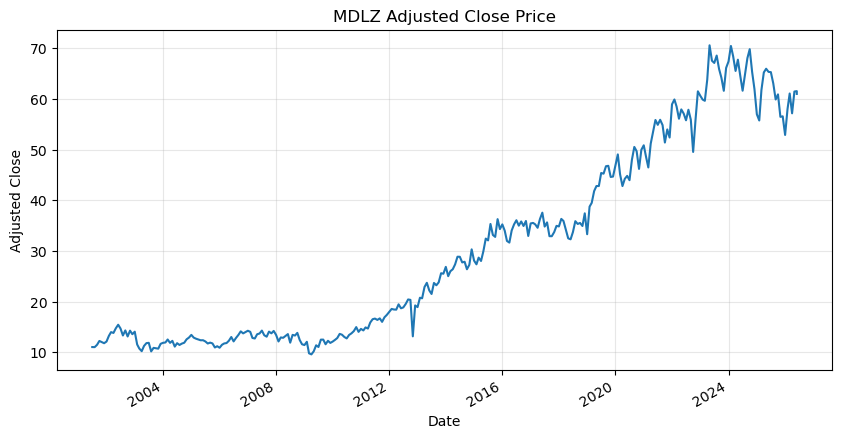

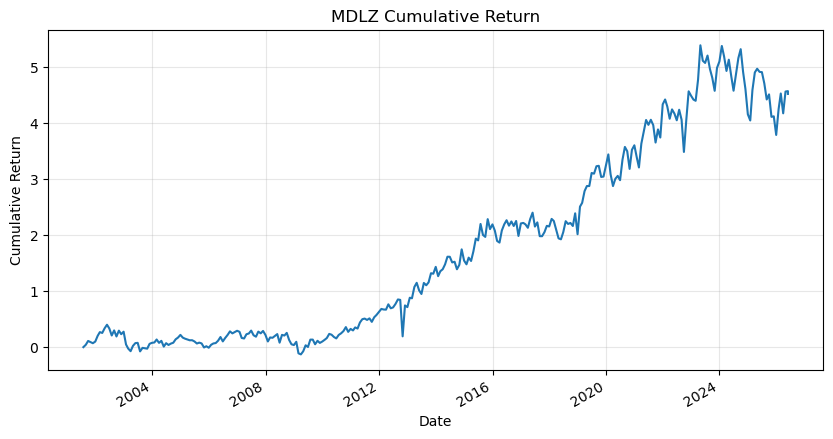

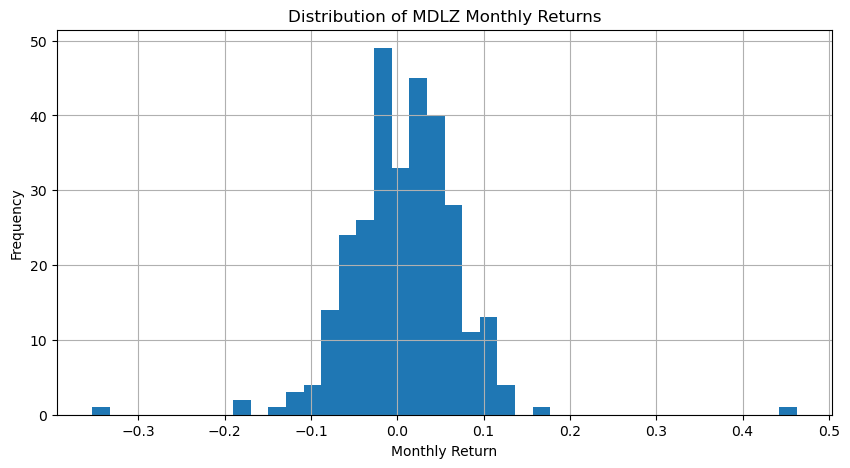

In [9]:
monthly_returns = prices["monthly_return"].dropna()

return_stats = pd.Series({
    "Monthly arithmetic mean": monthly_returns.mean(),
    "Monthly geometric mean": (1 + monthly_returns).prod() ** (1 / len(monthly_returns)) - 1,
    "Expected annual return, geometric": annualize_return(monthly_returns),
    "Annualized volatility": annualize_vol(monthly_returns),
    "Monthly skewness": monthly_returns.skew(),
    "Monthly excess kurtosis": monthly_returns.kurt(),
    "Monthly min": monthly_returns.min(),
    "Monthly max": monthly_returns.max(),
    "Positive months": (monthly_returns > 0).mean(),
    "Observations": len(monthly_returns),
}).to_frame("MDLZ")

display(return_stats)

fig, ax = plt.subplots(figsize=(10, 5))
prices["Adj Close"].plot(ax=ax)
ax.set_title("MDLZ Adjusted Close Price")
ax.set_ylabel("Adjusted Close")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
prices["cumulative_return"].plot(ax=ax)
ax.set_title("MDLZ Cumulative Return")
ax.set_ylabel("Cumulative Return")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_returns.hist(bins=40, ax=ax)
ax.set_title("Distribution of MDLZ Monthly Returns")
ax.set_xlabel("Monthly Return")
ax.set_ylabel("Frequency")
plt.show()

## Fama-French Five-Factor Return Analysis

The regression is:

\[
R_{i,t} - R_{f,t} = \alpha + \beta_m (Mkt-RF)_t + \beta_s SMB_t + \beta_h HML_t + \beta_r RMW_t + \beta_c CMA_t + \epsilon_t
\]

where all returns are monthly decimals. The notebook also reports an annualized version of alpha by multiplying monthly alpha by 12.

,coef_monthly,std_error,t_stat,coef_annualized_if_return
alpha,-0.0012,0.0034,-0.3552,-0.0147
Mkt-RF,0.7222,0.0831,8.6922,8.6668
SMB,-0.3480,0.1409,-2.4692,-4.1760
HML,-0.0276,0.1384,-0.1995,-0.3312
RMW,0.6111,0.1655,3.6913,7.3326
CMA,0.5456,0.2027,2.6921,6.5470
R-squared,0.2272,NaN,NaN,NaN


,mean,std,skew,kurt,annualized_mean_or_alpha,annualized_vol
MDLZ monthly return,0.0076,0.0642,0.4676,10.9036,0.0911,0.2225
MDLZ monthly excess return,0.0062,0.0643,0.4851,10.8742,0.0745,0.2228
Mkt-RF,0.0071,0.0443,-0.5046,1.0326,0.0847,0.1535
SMB,0.0009,0.0272,0.2146,0.2457,0.0113,0.0941
HML,0.0007,0.0309,-0.0681,2.6522,0.0080,0.1070
RMW,0.0033,0.0223,0.0932,1.9675,0.0397,0.0772
CMA,0.0012,0.0202,0.4066,1.5977,0.0145,0.0700


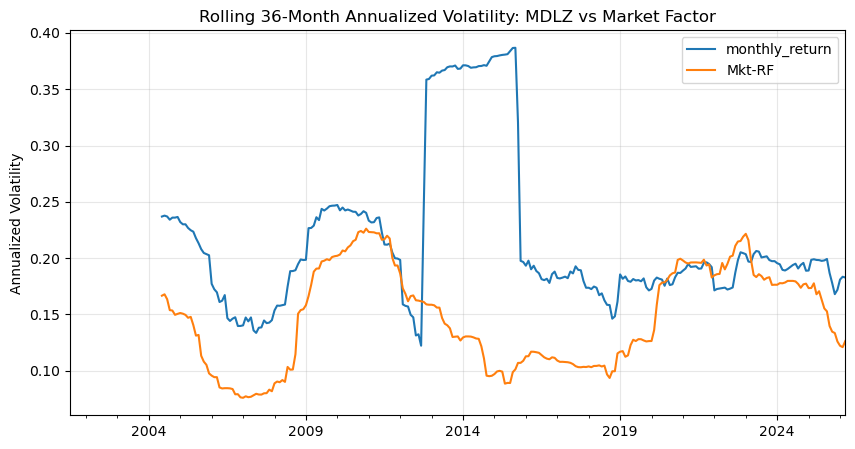

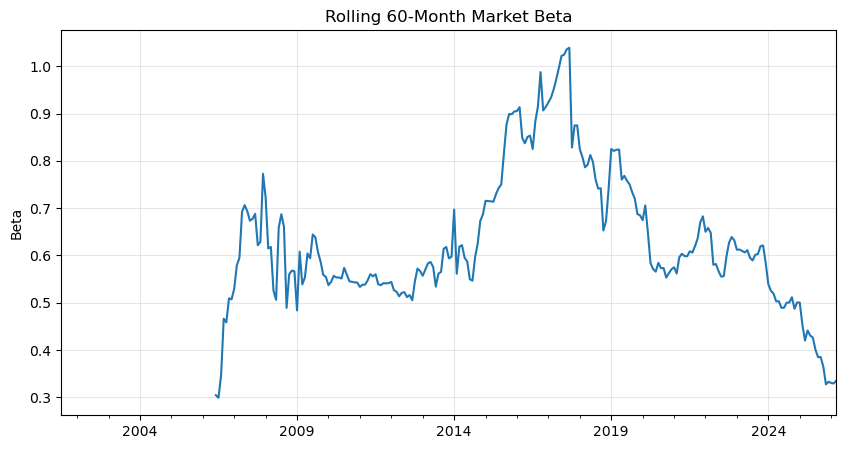

In [11]:
ff_data = prices[["monthly_return"]].join(ff5, how="inner").dropna()
ff_data["MDLZ_excess"] = ff_data["monthly_return"] - ff_data["RF"]

factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
ff_regression, ff_residuals, ff_r2 = ols(ff_data["MDLZ_excess"], ff_data[factor_cols], add_const=True)

factor_summary = ff_regression.copy()
factor_summary.loc["R-squared", "coef_monthly"] = ff_r2

display(factor_summary)

factor_return_stats = pd.DataFrame({
    "MDLZ monthly return": ff_data["monthly_return"],
    "MDLZ monthly excess return": ff_data["MDLZ_excess"],
    "Mkt-RF": ff_data["Mkt-RF"],
    "SMB": ff_data["SMB"],
    "HML": ff_data["HML"],
    "RMW": ff_data["RMW"],
    "CMA": ff_data["CMA"],
}).agg(["mean", "std", "skew", "kurt"]).T
factor_return_stats["annualized_mean_or_alpha"] = factor_return_stats["mean"] * 12
factor_return_stats["annualized_vol"] = factor_return_stats["std"] * np.sqrt(12)
display(factor_return_stats)

fig, ax = plt.subplots(figsize=(10, 5))
ff_data[["monthly_return", "Mkt-RF"]].rolling(36).std().mul(np.sqrt(12)).plot(ax=ax)
ax.set_title("Rolling 36-Month Annualized Volatility: MDLZ vs Market Factor")
ax.set_ylabel("Annualized Volatility")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
rolling_beta_cov = ff_data["MDLZ_excess"].rolling(60).cov(ff_data["Mkt-RF"])
rolling_beta_var = ff_data["Mkt-RF"].rolling(60).var()
rolling_market_beta = rolling_beta_cov / rolling_beta_var
rolling_market_beta.plot(ax=ax)
ax.set_title("Rolling 60-Month Market Beta")
ax.set_ylabel("Beta")
ax.grid(True, alpha=0.3)
plt.show()

## Build Annual Fundamentals Panel

In [13]:
fund = pd.DataFrame(index=income.index.union(balance.index).sort_values())

for col in [
    "Total Revenue", "Cost of Revenue", "Gross Profit", "Operating Income", "EBIT", "EBITDA",
    "Net Income", "Net Income Common Stockholders", "Pretax Income", "Tax Provision",
    "Interest Expense", "Interest Expense Non Operating", "Diluted EPS", "Basic EPS",
    "Diluted Average Shares", "Reconciled Depreciation"
]:
    fund[col] = sget(income.reindex(fund.index), col)

for col in [
    "Total Assets", "Current Assets", "Cash And Cash Equivalents", "Cash, Cash Equivalents & Short Term Investments",
    "Receivables", "Inventory", "Current Liabilities", "Accounts Payable", "Working Capital",
    "Total Liabilities Net Minority Interest", "Total Equity Gross Minority Interest", "Stockholders' Equity",
    "Common Stock Equity", "Total Debt", "Net Debt", "Net PPE", "Invested Capital",
    "Ordinary Shares Number", "Share Issued"
]:
    fund[col] = sget(balance.reindex(fund.index), col)

fund["Cash"] = fund["Cash And Cash Equivalents"].combine_first(
    fund["Cash, Cash Equivalents & Short Term Investments"]
)
fund["Net Income Used"] = fund["Net Income Common Stockholders"].combine_first(fund["Net Income"])
fund["Interest Expense Used"] = fund["Interest Expense"].combine_first(fund["Interest Expense Non Operating"])
fund["Equity Used"] = fund["Common Stock Equity"].combine_first(fund["Stockholders' Equity"]).combine_first(fund["Total Equity Gross Minority Interest"])
fund["Shares Used"] = fund["Ordinary Shares Number"].combine_first(fund["Diluted Average Shares"]).combine_first(fund["Share Issued"])

for col in ["Total Assets", "Receivables", "Inventory", "Accounts Payable", "Net PPE", "Working Capital", "Equity Used", "Invested Capital"]:
    fund[f"Avg {col}"] = (fund[col] + fund[col].shift(1)) / 2

fund["NWC"] = fund["Current Assets"] - fund["Current Liabilities"]
fund["Change NWC"] = fund["NWC"].diff()
fund["D&A"] = fund["Reconciled Depreciation"]
fund["Proxy CAPEX"] = fund["Net PPE"].diff() + fund["D&A"]
fund["Tax Rate Effective"] = fund["Tax Provision"] / fund["Pretax Income"].replace(0, np.nan)
fund["Tax Rate Effective"] = fund["Tax Rate Effective"].replace([np.inf, -np.inf], np.nan).clip(lower=0, upper=0.60)
fund["NOPAT"] = fund["EBIT"] * (1 - fund["Tax Rate Effective"])
fund["Proxy FCF"] = fund["NOPAT"] + fund["D&A"] - fund["Proxy CAPEX"] - fund["Change NWC"]

annual_price = prices["Adj Close"].resample("YE").last()
fund["Fiscal Year-End Share Price"] = annual_price.reindex(fund.index, method="nearest")
fund["Market Capitalization"] = fund["Fiscal Year-End Share Price"] * fund["Shares Used"]
fund["Enterprise Value"] = fund["Market Capitalization"] + fund["Total Debt"] - fund["Cash"]

display(fund.tail(8))

,Total Revenue,Cost of Revenue,Gross Profit,Operating Income,EBIT,EBITDA,Net Income,Net Income Common Stockholders,Pretax Income,Tax Provision,Interest Expense,Interest Expense Non Operating,Diluted EPS,Basic EPS,Diluted Average Shares,Reconciled Depreciation,Total Assets,Current Assets,Cash And Cash Equivalents,"Cash, Cash Equivalents & Short Term Investments",Receivables,Inventory,Current Liabilities,Accounts Payable,Working Capital,Total Liabilities Net Minority Interest,Total Equity Gross Minority Interest,Stockholders' Equity,Common Stock Equity,Total Debt,Net Debt,Net PPE,Invested Capital,Ordinary Shares Number,Share Issued,Cash,Net Income Used,Interest Expense Used,Equity Used,Shares Used,Avg Total Assets,Avg Receivables,Avg Inventory,Avg Accounts Payable,Avg Net PPE,Avg Working Capital,Avg Equity Used,Avg Invested Capital,NWC,Change NWC,D&A,Proxy CAPEX,Tax Rate Effective,NOPAT,Proxy FCF,Fiscal Year-End Share Price,Market Capitalization,Enterprise Value
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-31,"25,938,000,000.0000","15,586,000,000.0000","10,352,000,000.0000","3,701,000,000.0000","3,304,000,000.0000","4,115,000,000.0000","3,317,000,000.0000","3,317,000,000.0000","2,842,000,000.0000","773,000,000.0000","462,000,000.0000","462,000,000.0000",2.2800,2.3000,"1,486,000,000.0000","811,000,000.0000","62,729,000,000.0000","7,604,000,000.0000","1,100,000,000.0000","1,100,000,000.0000","3,006,000,000.0000","2,592,000,000.0000","16,737,000,000.0000","5,794,000,000.0000","-9,133,000,000.0000","37,016,000,000.0000","25,713,000,000.0000","25,637,000,000.0000","25,637,000,000.0000","18,372,000,000.0000","17,272,000,000.0000","8,482,000,000.0000","44,009,000,000.0000","1,450,999,855.0000","1,996,537,778.0000","1,100,000,000.0000","3,317,000,000.0000","462,000,000.0000","25,637,000,000.0000","1,450,999,855.0000","62,843,000,000.0000","3,266,000,000.0000","2,574,500,000.0000","5,749,500,000.0000","8,579,500,000.0000","-8,703,000,000.0000","25,815,500,000.0000","43,827,500,000.0000","-9,133,000,000.0000","-860,000,000.0000","811,000,000.0000","616,000,000.0000",0.2720,"2,405,339,901.4778","3,460,339,901.4778",33.3067,"48,328,053,145.5249","65,600,053,145.5249"
2019-12-31,"25,868,000,000.0000","15,531,000,000.0000","10,337,000,000.0000","4,027,000,000.0000","3,931,000,000.0000","4,978,000,000.0000","3,929,000,000.0000","3,929,000,000.0000","3,447,000,000.0000","2,000,000.0000","484,000,000.0000","484,000,000.0000",2.6500,2.6800,"1,458,000,000.0000","1,047,000,000.0000","64,515,000,000.0000","7,630,000,000.0000","1,291,000,000.0000","1,291,000,000.0000","2,927,000,000.0000","2,546,000,000.0000","15,322,000,000.0000","5,853,000,000.0000","-7,692,000,000.0000","37,198,000,000.0000","27,317,000,000.0000","27,241,000,000.0000","27,241,000,000.0000","18,829,000,000.0000","17,012,000,000.0000","9,301,000,000.0000","45,544,000,000.0000","1,435,006,254.0000","1,996,537,778.0000","1,291,000,000.0000","3,929,000,000.0000","484,000,000.0000","27,241,000,000.0000","1,435,006,254.0000","63,622,000,000.0000","2,966,500,000.0000","2,569,000,000.0000","5,823,500,000.0000","8,891,500,000.0000","-8,412,500,000.0000","26,439,000,000.0000","44,776,500,000.0000","-7,692,000,000.0000","1,441,000,000.0000","1,047,000,000.0000","1,866,000,000.0000",0.0006,"3,928,719,176.0952","1,668,719,176.0952",46.8321,"67,204,377,913.0472","84,742,377,913.0472"
2020-12-31,"26,581,000,000.0000","16,135,000,000.0000","10,446,000,000.0000","4,154,000,000.0000","3,806,000,000.0000","4,922,000,000.0000","3,555,000,000.0000","3,555,000,000.0000","3,383,000,000.0000","1,224,000,000.0000","423,000,000.0000","423,000,000.0000",2.4700,2.4800,"1,441,000,000.0000","1,116,000,000.0000","67,810,000,000.0000","9,979,000,000.0000","3,619,000,000.0000","3,619,000,000.0000","2,954,000,000.0000","2,647,000,000.0000","15,159,000,000.0000","6,209,000,000.0000","-5,180,000,000.0000","40,156,000,000.0000","27,654,000,000.0000","27,578,000,000.0000","27,578,000,000.0000"

## Growth Analysis

,Latest,1Y Growth,3Y CAGR,5Y CAGR,10Y CAGR
Metric,,,,,
Revenue,"38,537,000,000.0000",0.0575,0.0696,0.0771,0.0266
Gross Profit,"10,935,000,000.0000",-0.2330,-0.0112,0.0092,-0.0051
Operating Income,"3,620,000,000.0000",-0.4569,-0.0157,-0.0271,-0.0036
EBITDA,"4,971,000,000.0000",-0.3841,0.0143,0.0020,-0.0616
Net Income,"2,451,000,000.0000",-0.4684,-0.0338,-0.0717,-0.1030
Diluted EPS,1.8900,-0.4474,-0.0120,-0.0521,-0.0819
Proxy FCF,"4,131,585,932.3159",-0.0407,-0.0762,NaN,-0.0752
Total Assets,"71,487,000,000.0000",0.0437,0.0015,0.0106,0.0130
Total Debt,"21,804,000,000.0000",0.1868,-0.0239,0.0123,0.0354


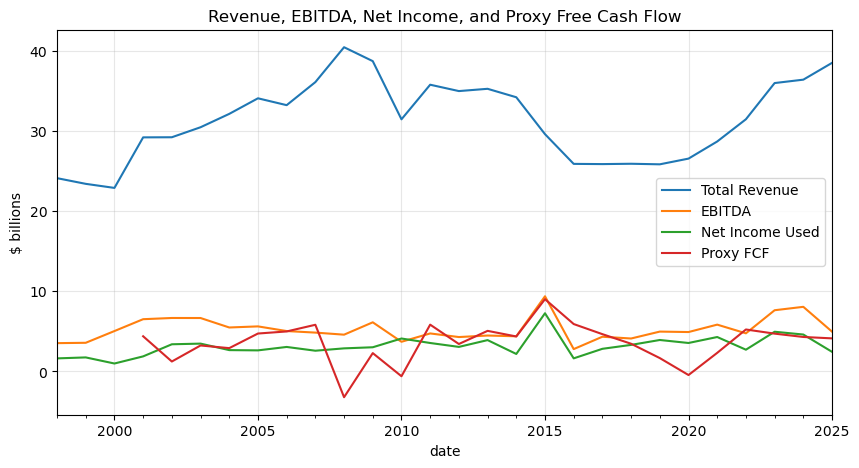

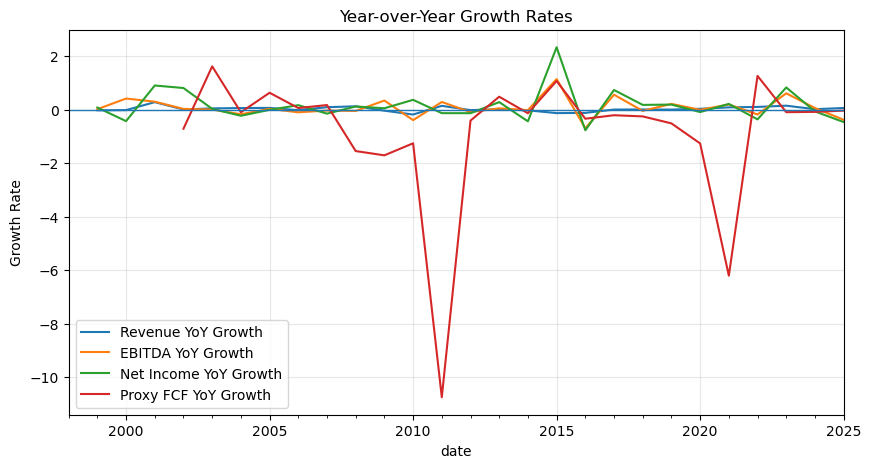

In [15]:
growth_items = {
    "Revenue": "Total Revenue",
    "Gross Profit": "Gross Profit",
    "Operating Income": "Operating Income",
    "EBITDA": "EBITDA",
    "Net Income": "Net Income Used",
    "Diluted EPS": "Diluted EPS",
    "Proxy FCF": "Proxy FCF",
    "Total Assets": "Total Assets",
    "Total Debt": "Total Debt",
    "Book Equity": "Equity Used",
}

growth = pd.DataFrame(index=fund.index)
for label, col in growth_items.items():
    growth[f"{label} YoY Growth"] = fund[col].pct_change()

growth_summary = []
for label, col in growth_items.items():
    s = fund[col]
    growth_summary.append({
        "Metric": label,
        "Latest": s.dropna().iloc[-1] if s.dropna().size else np.nan,
        "1Y Growth": s.pct_change().dropna().iloc[-1] if s.pct_change().dropna().size else np.nan,
        "3Y CAGR": trailing_cagr(s, 3),
        "5Y CAGR": trailing_cagr(s, 5),
        "10Y CAGR": trailing_cagr(s, 10),
    })
growth_summary = pd.DataFrame(growth_summary).set_index("Metric")
display(growth_summary)

fig, ax = plt.subplots(figsize=(10, 5))
(fund[["Total Revenue", "EBITDA", "Net Income Used", "Proxy FCF"]] / 1e9).plot(ax=ax)
ax.set_title("Revenue, EBITDA, Net Income, and Proxy Free Cash Flow")
ax.set_ylabel("$ billions")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
growth[["Revenue YoY Growth", "EBITDA YoY Growth", "Net Income YoY Growth", "Proxy FCF YoY Growth"]].plot(ax=ax)
ax.axhline(0, linewidth=1)
ax.set_title("Year-over-Year Growth Rates")
ax.set_ylabel("Growth Rate")
ax.grid(True, alpha=0.3)
plt.show()

## Ratio Analysis

The following panel calculates more than 25 financial ratios across liquidity, asset efficiency, profitability, leverage, and market valuation. Some ratios require market values and therefore begin once both share prices and shares outstanding are available.

Number of ratios calculated: 36


date,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31,2025-12-31
Current Ratio,0.4543,0.4980,0.6583,0.7383,0.6031,0.6155,0.6774,0.5923
Quick Ratio,0.2995,0.3318,0.4837,0.5450,0.4011,0.4254,0.4816,0.3902
Cash Ratio,0.0657,0.0843,0.2387,0.2531,0.1149,0.0952,0.0691,0.0972
Working Capital / Assets,-0.1456,-0.1192,-0.0764,-0.0546,-0.0933,-0.1024,-0.0921,-0.1247
Net Debt / Total Capital,0.4025,0.3844,0.3696,0.3575,0.4387,0.3831,0.3784,0.4248
Asset Turnover,0.4127,0.4066,0.4018,0.4258,0.4556,0.5053,0.5210,0.5506
Receivables Turnover,7.9418,8.7200,9.0396,9.3520,8.8784,8.5559,7.8174,7.9712
Inventory Turnover,6.0540,6.0455,6.2141,6.5232,6.6297,6.3613,5.9618,6.6946
Payables Turnover,2.7108,2.6670,2.6753,2.6997,2.8245,2.8020,2.4990,2.8206
PPE Turnover,3.0233,2.9093,2.8032,3.0335,3.3239,3.5914,3.5337,3.5607


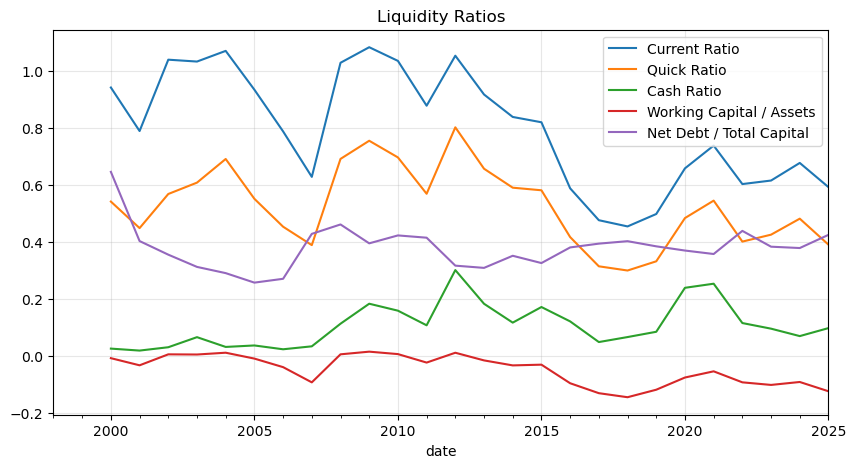

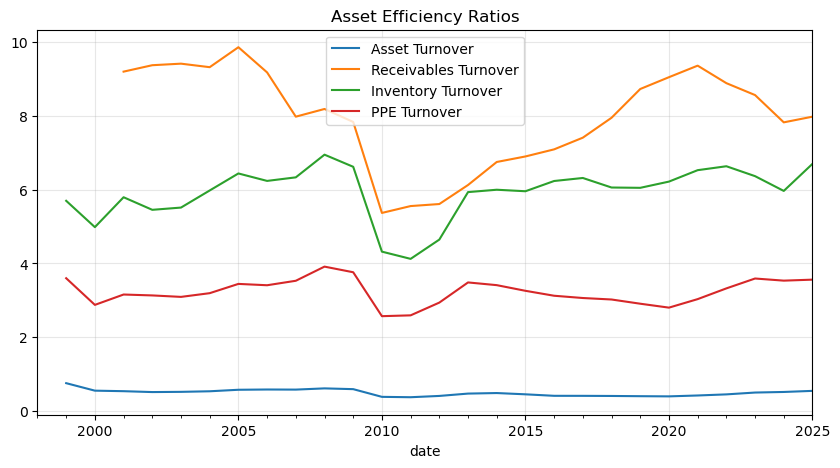

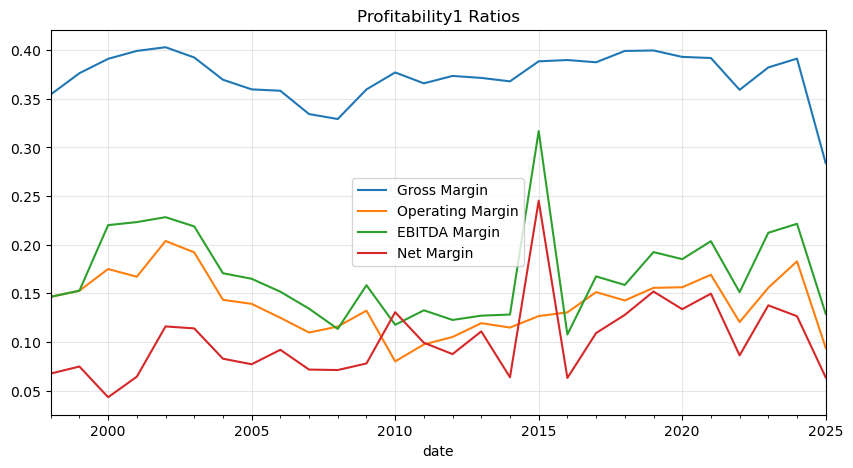

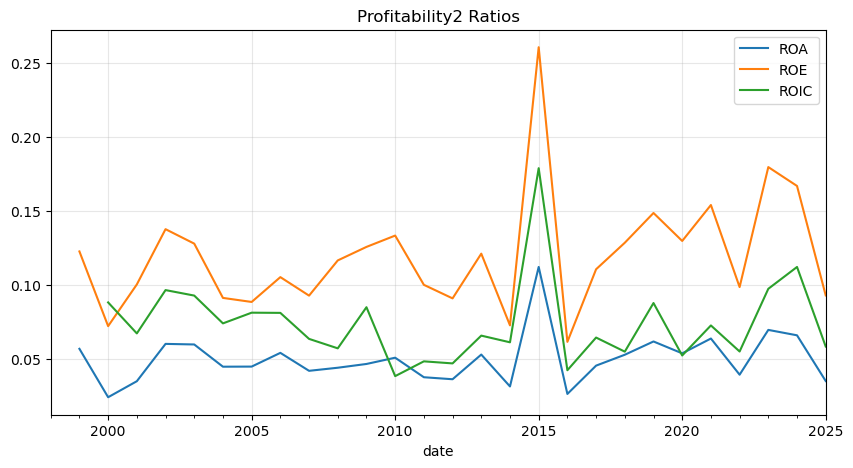

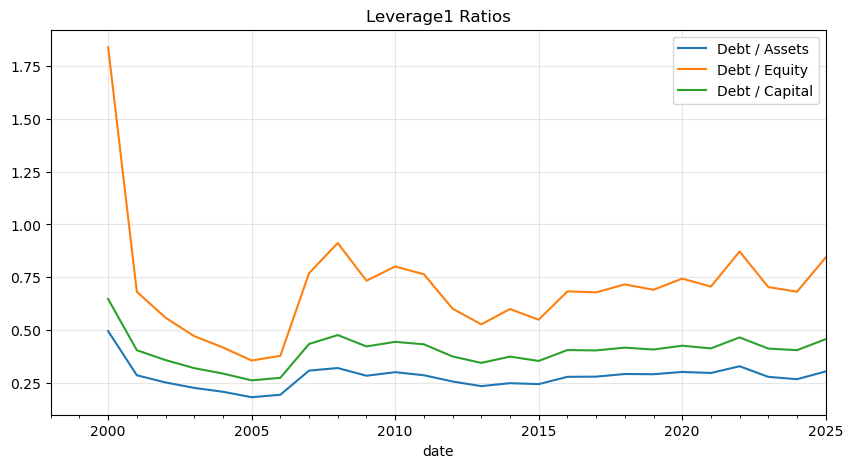

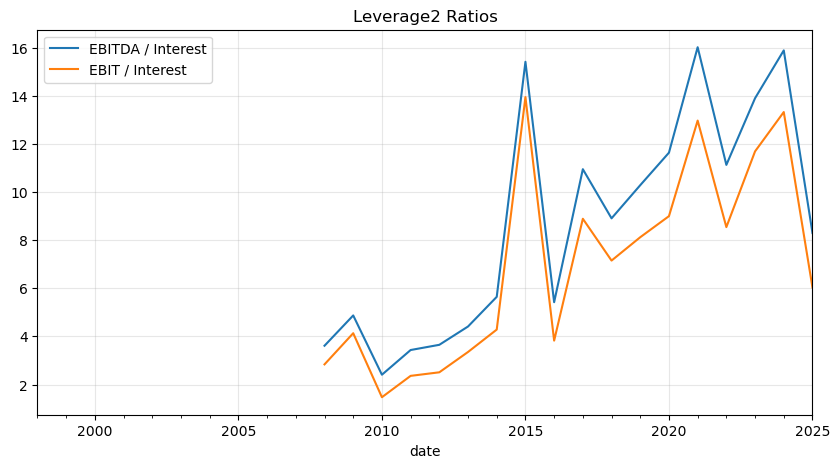

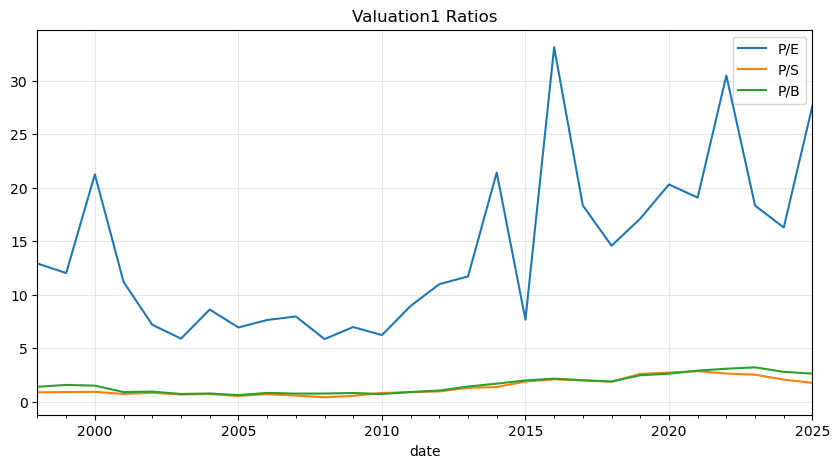

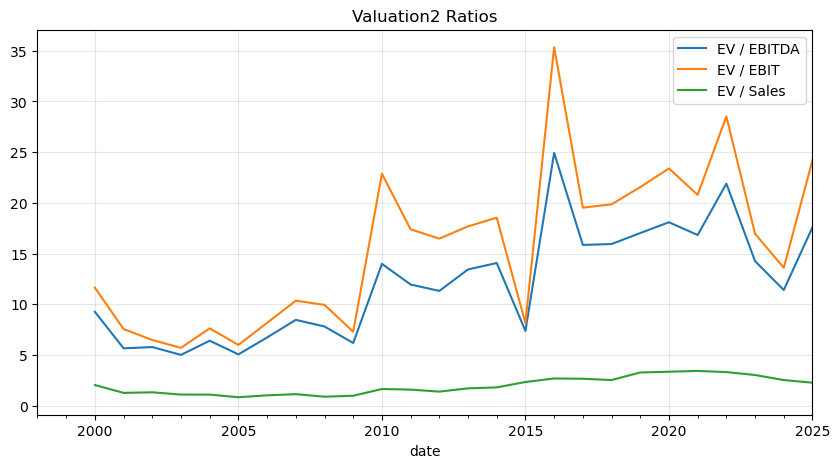

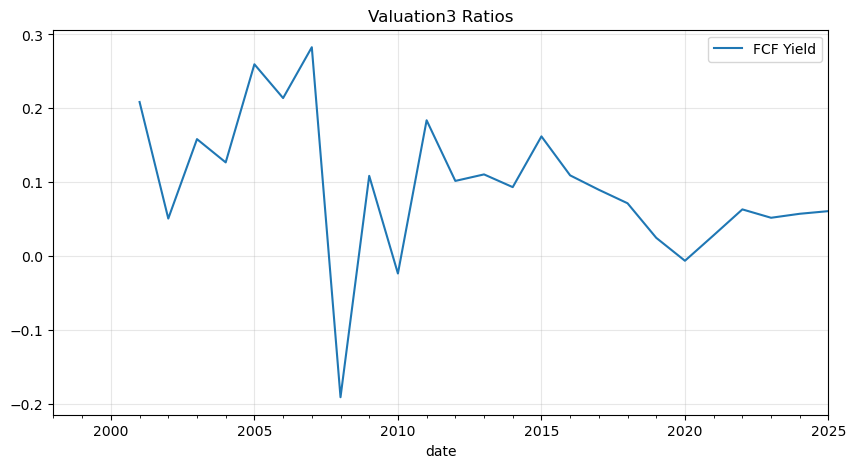

In [21]:
ratios = pd.DataFrame(index=fund.index)

# Liquidity
ratios["Current Ratio"] = fund["Current Assets"] / fund["Current Liabilities"]
ratios["Quick Ratio"] = (fund["Current Assets"] - fund["Inventory"]) / fund["Current Liabilities"]
ratios["Cash Ratio"] = fund["Cash"] / fund["Current Liabilities"]
ratios["Working Capital / Assets"] = fund["Working Capital"] / fund["Total Assets"]
ratios["Net Debt / Total Capital"] = fund["Net Debt"] / (fund["Net Debt"] + fund["Equity Used"])

# Asset efficiency
ratios["Asset Turnover"] = fund["Total Revenue"] / fund["Avg Total Assets"]
ratios["Receivables Turnover"] = fund["Total Revenue"] / fund["Avg Receivables"]
#ratios["Days Sales Outstanding"] = 365 / ratios["Receivables Turnover"]
ratios["Inventory Turnover"] = fund["Cost of Revenue"] / fund["Avg Inventory"]
#ratios["Days Inventory Outstanding"] = 365 / ratios["Inventory Turnover"]
ratios["Payables Turnover"] = fund["Cost of Revenue"] / fund["Avg Accounts Payable"]
#ratios["Days Payables Outstanding"] = 365 / ratios["Payables Turnover"]
#ratios["Cash Conversion Cycle"] = ratios["Days Sales Outstanding"] + ratios["Days Inventory Outstanding"] - ratios["Days Payables Outstanding"]
ratios["PPE Turnover"] = fund["Total Revenue"] / fund["Avg Net PPE"]
ratios["Working Capital Turnover"] = fund["Total Revenue"] / fund["Avg Working Capital"]

# Profitability
ratios["Gross Margin"] = fund["Gross Profit"] / fund["Total Revenue"]
ratios["Operating Margin"] = fund["Operating Income"] / fund["Total Revenue"]
ratios["EBIT Margin"] = fund["EBIT"] / fund["Total Revenue"]
ratios["EBITDA Margin"] = fund["EBITDA"] / fund["Total Revenue"]
ratios["Net Margin"] = fund["Net Income Used"] / fund["Total Revenue"]
ratios["ROA"] = fund["Net Income Used"] / fund["Avg Total Assets"]
ratios["ROE"] = fund["Net Income Used"] / fund["Avg Equity Used"]
ratios["ROIC"] = fund["NOPAT"] / fund["Avg Invested Capital"]
ratios["Effective Tax Rate"] = fund["Tax Rate Effective"]

# Leverage and coverage
ratios["Debt / Assets"] = fund["Total Debt"] / fund["Total Assets"]
ratios["Debt / Equity"] = fund["Total Debt"] / fund["Equity Used"]
ratios["Liabilities / Assets"] = fund["Total Liabilities Net Minority Interest"] / fund["Total Assets"]
ratios["Equity Multiplier"] = fund["Total Assets"] / fund["Equity Used"]
ratios["Debt / Capital"] = fund["Total Debt"] / (fund["Total Debt"] + fund["Equity Used"])
ratios["Net Debt / EBITDA"] = fund["Net Debt"] / fund["EBITDA"]
ratios["EBITDA / Interest"] = fund["EBITDA"] / fund["Interest Expense Used"].abs()
ratios["EBIT / Interest"] = fund["EBIT"] / fund["Interest Expense Used"].abs()

# Market valuation
ratios["P/E"] = fund["Market Capitalization"] / fund["Net Income Used"]
ratios["P/S"] = fund["Market Capitalization"] / fund["Total Revenue"]
ratios["P/B"] = fund["Market Capitalization"] / fund["Equity Used"]
ratios["EV / EBITDA"] = fund["Enterprise Value"] / fund["EBITDA"]
ratios["EV / EBIT"] = fund["Enterprise Value"] / fund["EBIT"]
ratios["EV / Sales"] = fund["Enterprise Value"] / fund["Total Revenue"]
ratios["FCF Yield"] = fund["Proxy FCF"] / fund["Market Capitalization"]
ratios["Earnings Yield"] = fund["Net Income Used"] / fund["Market Capitalization"]

ratio_groups = {
    "Liquidity": ["Current Ratio", "Quick Ratio", "Cash Ratio", "Working Capital / Assets", "Net Debt / Total Capital"],
    "Asset Efficiency": ["Asset Turnover", "Receivables Turnover", "Inventory Turnover", "PPE Turnover"],
    "Profitability1": ["Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin"],
    "Profitability2": ["ROA", "ROE", "ROIC"],
    "Leverage1": ["Debt / Assets", "Debt / Equity", "Debt / Capital"],
    "Leverage2": ["EBITDA / Interest", "EBIT / Interest"],
    "Valuation1": ["P/E", "P/S", "P/B"],
    "Valuation2": ["EV / EBITDA", "EV / EBIT", "EV / Sales"],
    "Valuation3": ["FCF Yield"],
}

print(f"Number of ratios calculated: {ratios.shape[1]}")
display(ratios.tail(8).T)

for group, cols in ratio_groups.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    ratios[cols].replace([np.inf, -np.inf], np.nan).plot(ax=ax)
    ax.set_title(f"{group} Ratios")
    ax.grid(True, alpha=0.3)
    plt.show()

## WACC Estimation

,Estimate
Latest fiscal date,2025-12-31 00:00:00
Latest share price,52.8811
Shares used,"1,281,576,414.0000"
Market capitalization,"67,771,165,380.0697"
Book/face debt used as debt value,"21,804,000,000.0000"
Equity weight,0.7566
Debt weight,0.2434
Annual risk-free rate,0.0354
Annual equity risk premium,0.0847
FF5 market beta,0.7222


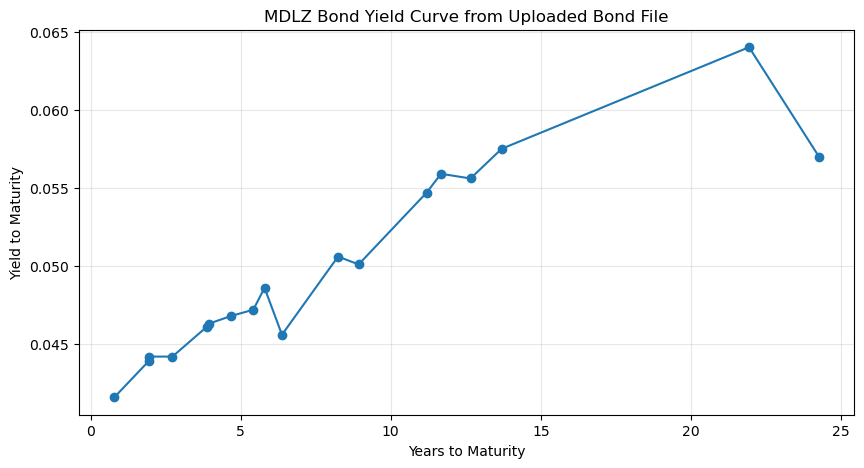

In [23]:
latest_date = fund.dropna(how="all").index.max()
latest = fund.loc[latest_date].copy()

latest_monthly_rf = ff5["RF"].dropna().iloc[-1]
annual_rf = (1 + latest_monthly_rf) ** 12 - 1
if ASSUMPTIONS["risk_free_rate_override"] is not None:
    annual_rf = ASSUMPTIONS["risk_free_rate_override"]

historical_monthly_erp = ff_data["Mkt-RF"].mean()
annual_erp = historical_monthly_erp * 12
if ASSUMPTIONS["equity_risk_premium_override"] is not None:
    annual_erp = ASSUMPTIONS["equity_risk_premium_override"]

market_beta = ff_regression.loc["Mkt-RF", "coef_monthly"]
cost_of_equity = annual_rf + market_beta * annual_erp

if bonds["Yield"].dropna().empty:
    pretax_cost_of_debt = ASSUMPTIONS["default_pretax_cost_of_debt_if_missing"]
else:
    if ASSUMPTIONS["bond_yield_weighting"] == "market_value":
        pretax_cost_of_debt = (bonds["Yield"] * bonds["yield_weight"]).sum()
    else:
        pretax_cost_of_debt = bonds["Yield"].mean()

tax_rate = latest["Tax Rate Effective"]
if pd.isna(tax_rate):
    tax_rate = fund["Tax Rate Effective"].dropna().tail(5).median()
tax_rate = float(np.clip(tax_rate, ASSUMPTIONS["tax_rate_floor"], ASSUMPTIONS["tax_rate_cap"]))
if ASSUMPTIONS["marginal_tax_rate_override"] is not None:
    tax_rate = ASSUMPTIONS["marginal_tax_rate_override"]

after_tax_cost_of_debt = pretax_cost_of_debt * (1 - tax_rate)

market_cap = latest["Market Capitalization"]
market_debt = latest["Total Debt"]  # approximation; replace with market value of debt if full amounts are available.
enterprise_capital = market_cap + market_debt

equity_weight = market_cap / enterprise_capital
debt_weight = market_debt / enterprise_capital

if ASSUMPTIONS["target_equity_weight_override"] is not None:
    equity_weight = ASSUMPTIONS["target_equity_weight_override"]
if ASSUMPTIONS["target_debt_weight_override"] is not None:
    debt_weight = ASSUMPTIONS["target_debt_weight_override"]
if ASSUMPTIONS["target_equity_weight_override"] is not None or ASSUMPTIONS["target_debt_weight_override"] is not None:
    total_weight = equity_weight + debt_weight
    equity_weight = equity_weight / total_weight
    debt_weight = debt_weight / total_weight

wacc = equity_weight * cost_of_equity + debt_weight * after_tax_cost_of_debt

wacc_summary = pd.Series({
    "Latest fiscal date": latest_date,
    "Latest share price": latest["Fiscal Year-End Share Price"],
    "Shares used": latest["Shares Used"],
    "Market capitalization": market_cap,
    "Book/face debt used as debt value": market_debt,
    "Equity weight": equity_weight,
    "Debt weight": debt_weight,
    "Annual risk-free rate": annual_rf,
    "Annual equity risk premium": annual_erp,
    "FF5 market beta": market_beta,
    "Cost of equity": cost_of_equity,
    "Pretax cost of debt": pretax_cost_of_debt,
    "Tax rate": tax_rate,
    "After-tax cost of debt": after_tax_cost_of_debt,
    "WACC": wacc,
}).to_frame("Estimate")

display(wacc_summary)

fig, ax = plt.subplots(figsize=(10, 5))
bonds.sort_values("years_to_maturity").plot(x="years_to_maturity", y="Yield", marker="o", legend=False, ax=ax)
ax.set_title("MDLZ Bond Yield Curve from Uploaded Bond File")
ax.set_xlabel("Years to Maturity")
ax.set_ylabel("Yield to Maturity")
ax.grid(True, alpha=0.3)
plt.show()

## DCF Valuation

The base-case DCF projects revenue, EBIT, taxes, D&A, CAPEX, and NWC. Historical median relationships supply default assumptions, but each assumption can be overwritten in the `ASSUMPTIONS` dictionary.

Important caveat: because the uploaded files do not include a cash-flow statement, CAPEX and free cash flow are proxies derived from income-statement and balance-sheet data. This is suitable for a first-pass teaching/research model, not a final investment-banking model.

,Base Case
Base revenue growth,0.0788
EBIT margin,0.1476
Tax rate,0.2595
D&A / Revenue,0.0355
CAPEX / Revenue,0.0506
NWC / Revenue,-0.2313
WACC,0.0820
Terminal growth,0.0250
Projection years,5.0000
Terminal FCF,"6,409,355,051.4454"


,Revenue,Revenue Growth,EBIT,EBIT Margin,Taxes,NOPAT,D&A,CAPEX,NWC,Change in NWC,FCF,Discount Factor,PV FCF
Year,,,,,,,,,,,,,
1,"41,573,409,944.4259",0.0788,"6,135,170,988.0105",0.1476,"1,591,806,142.2111","4,543,364,845.7994","1,475,187,717.5392","2,104,043,017.9880","-9,615,273,706.6888","-702,273,706.6888","4,616,783,252.0394",0.9242,"4,266,791,551.7027"
2,"44,849,064,909.2375",0.0788,"6,618,573,800.8591",0.1476,"1,717,227,840.8334","4,901,345,960.0257","1,591,420,809.2545","2,269,824,919.6233","-10,372,881,011.3925","-757,607,304.7037","4,980,549,154.3606",0.8541,"4,254,035,521.3308"
3,"48,382,815,504.4736",0.0788,"7,140,064,921.2588",0.1476,"1,852,531,774.5270","5,287,533,146.7318","1,716,812,146.6961","2,448,669,120.2110","-11,190,181,762.7572","-817,300,751.3646","5,372,976,924.5815",0.7894,"4,241,317,626.4780"
4,"52,194,997,618.7301",0.0788,"7,702,645,405.7479",0.1476,"1,998,496,585.0348","5,704,148,820.7131","1,852,083,326.9887","2,641,604,825.3053","-12,071,879,330.9220","-881,697,568.1649","5,796,324,890.5615",0.7295,"4,228,637,753.1341"
5,"56,307,549,447.3311",0.0788,"8,309,552,770.3170",0.1476,"2,155,962,264.8931","6,153,590,505.4239","1,998,012,803.3874","2,849,742,333.6946","-13,023,047,674.2887","-951,168,343.3667","6,253,029,318.4833",0.6742,"4,215,995,787.6297"


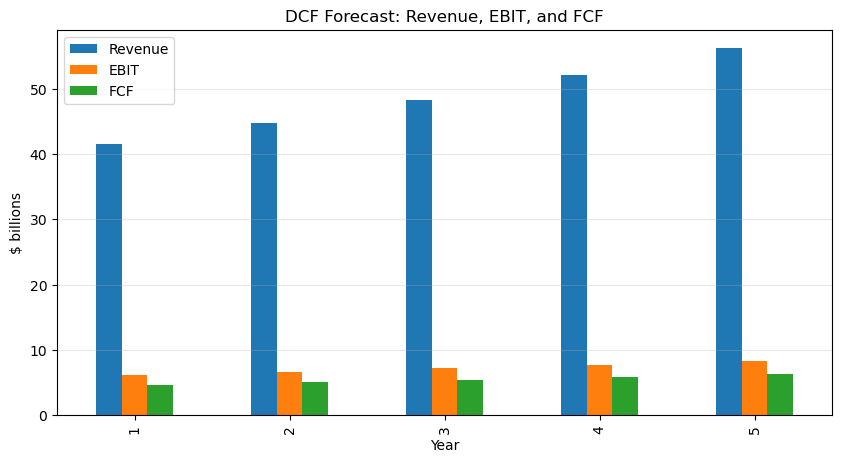

In [25]:
hist = fund.copy().dropna(subset=["Total Revenue"]).tail(8)

recent_revenue_cagr = trailing_cagr(fund["Total Revenue"], 5)
recent_revenue_median_growth = fund["Total Revenue"].pct_change().dropna().tail(5).median()
base_revenue_growth = ASSUMPTIONS["base_revenue_growth"]
if base_revenue_growth is None:
    base_revenue_growth = np.nanmedian([recent_revenue_cagr, recent_revenue_median_growth])

ebit_margin = ASSUMPTIONS["ebit_margin_override"]
if ebit_margin is None:
    ebit_margin = (hist["EBIT"] / hist["Total Revenue"]).replace([np.inf, -np.inf], np.nan).median()

da_percent_revenue = ASSUMPTIONS["da_percent_revenue"]
if da_percent_revenue is None:
    da_percent_revenue = (hist["D&A"] / hist["Total Revenue"]).replace([np.inf, -np.inf], np.nan).median()

capex_percent_revenue = ASSUMPTIONS["capex_percent_revenue"]
if capex_percent_revenue is None:
    capex_percent_revenue = (hist["Proxy CAPEX"] / hist["Total Revenue"]).replace([np.inf, -np.inf], np.nan).median()

nwc_percent_revenue = ASSUMPTIONS["nwc_percent_revenue"]
if nwc_percent_revenue is None:
    nwc_percent_revenue = latest["NWC"] / latest["Total Revenue"]

terminal_growth = ASSUMPTIONS["terminal_growth_rate"]
projection_years = ASSUMPTIONS["projection_years"]

if wacc <= terminal_growth:
    raise ValueError("WACC must exceed terminal growth for a Gordon-growth terminal value.")

last_revenue = latest["Total Revenue"]
last_nwc = latest["NWC"]

forecast_rows = []
prev_revenue = last_revenue
prev_nwc = last_nwc

for year in range(1, projection_years + 1):
    revenue = prev_revenue * (1 + base_revenue_growth)
    ebit = revenue * ebit_margin
    taxes = ebit * tax_rate
    nopat = ebit - taxes
    da = revenue * da_percent_revenue
    capex = revenue * capex_percent_revenue
    nwc = revenue * nwc_percent_revenue
    delta_nwc = nwc - prev_nwc
    fcf = nopat + da - capex - delta_nwc
    discount_factor = 1 / ((1 + wacc) ** year)
    pv_fcf = fcf * discount_factor

    forecast_rows.append({
        "Year": year,
        "Revenue": revenue,
        "Revenue Growth": base_revenue_growth,
        "EBIT": ebit,
        "EBIT Margin": ebit_margin,
        "Taxes": taxes,
        "NOPAT": nopat,
        "D&A": da,
        "CAPEX": capex,
        "NWC": nwc,
        "Change in NWC": delta_nwc,
        "FCF": fcf,
        "Discount Factor": discount_factor,
        "PV FCF": pv_fcf,
    })
    prev_revenue = revenue
    prev_nwc = nwc

dcf = pd.DataFrame(forecast_rows).set_index("Year")
terminal_fcf = dcf["FCF"].iloc[-1] * (1 + terminal_growth)
terminal_value = terminal_fcf / (wacc - terminal_growth)
pv_terminal_value = terminal_value / ((1 + wacc) ** projection_years)

enterprise_value_dcf = dcf["PV FCF"].sum() + pv_terminal_value
equity_value_dcf = enterprise_value_dcf - latest["Total Debt"] + latest["Cash"]
shares = ASSUMPTIONS["shares_for_intrinsic_value"] or latest["Shares Used"]
intrinsic_value_per_share = equity_value_dcf / shares

dcf_assumptions = pd.Series({
    "Base revenue growth": base_revenue_growth,
    "EBIT margin": ebit_margin,
    "Tax rate": tax_rate,
    "D&A / Revenue": da_percent_revenue,
    "CAPEX / Revenue": capex_percent_revenue,
    "NWC / Revenue": nwc_percent_revenue,
    "WACC": wacc,
    "Terminal growth": terminal_growth,
    "Projection years": projection_years,
    "Terminal FCF": terminal_fcf,
    "Terminal value": terminal_value,
    "PV terminal value": pv_terminal_value,
    "DCF enterprise value": enterprise_value_dcf,
    "Less debt": latest["Total Debt"],
    "Plus cash": latest["Cash"],
    "DCF equity value": equity_value_dcf,
    "Shares": shares,
    "Intrinsic value / share": intrinsic_value_per_share,
    "Latest market price": latest["Fiscal Year-End Share Price"],
    "Implied upside / downside": intrinsic_value_per_share / latest["Fiscal Year-End Share Price"] - 1,
}).to_frame("Base Case")

display(dcf_assumptions)
display(dcf)

fig, ax = plt.subplots(figsize=(10, 5))
(dcf[["Revenue", "EBIT", "FCF"]] / 1e9).plot(kind="bar", ax=ax)
ax.set_title("DCF Forecast: Revenue, EBIT, and FCF")
ax.set_ylabel("$ billions")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

## DCF Sensitivity Tables

Intrinsic value per share sensitivity: WACC vs. terminal growth


,WACC=6.2%,WACC=6.7%,WACC=7.2%,WACC=7.7%,WACC=8.2%,WACC=8.7%,WACC=9.2%,WACC=9.7%,WACC=10.2%
g=1.5%,80.0938,70.7206,62.9944,56.5169,51.0085,46.2674,42.1442,38.5256,35.3248
g=2.0%,89.7966,78.4126,69.2200,61.6425,55.2894,49.8866,45.2362,41.1916,37.6419
g=2.5%,102.1200,87.9348,76.7696,67.7534,60.3210,54.0893,48.7896,44.2276,40.2598
g=3.0%,118.2912,100.0288,86.1154,75.1637,66.3197,59.0289,52.9158,47.7166,43.2411
g=3.5%,140.4457,115.8990,97.9854,84.3372,73.5940,64.9180,57.7656,51.7682,46.6672


Intrinsic value per share sensitivity: WACC vs. revenue growth


,WACC=6.2%,WACC=6.7%,WACC=7.2%,WACC=7.7%,WACC=8.2%,WACC=8.7%,WACC=9.2%,WACC=9.7%,WACC=10.2%
Rev g=5.9%,88.3075,75.8550,66.0524,58.1358,51.6089,46.1357,41.4803,37.4724,33.9859
Rev g=6.4%,91.6421,78.7719,68.6408,60.4591,53.7139,48.0578,43.2471,39.1056,35.5030
Rev g=6.9%,95.0548,81.7568,71.2892,62.8359,55.8670,50.0236,45.0537,40.7754,37.0539
Rev g=7.4%,98.5470,84.8107,73.9984,65.2670,58.0691,52.0339,46.9010,42.4826,38.6394
Rev g=7.9%,102.1200,87.9348,76.7696,67.7534,60.3210,54.0893,48.7896,44.2276,40.2598
Rev g=8.4%,105.7751,91.1304,79.6037,70.2960,62.6235,56.1906,50.7200,46.0112,41.9158
Rev g=8.9%,109.5137,94.3986,82.5019,72.8957,64.9773,58.3386,52.6932,47.8340,43.6079
Rev g=9.4%,113.3372,97.7405,85.4651,75.5534,67.3835,60.5341,54.7096,49.6966,45.3368
Rev g=9.9%,117.2470,101.1575,88.4945,78.2701,69.8427,62.7777,56.7701,51.5996,47.1031


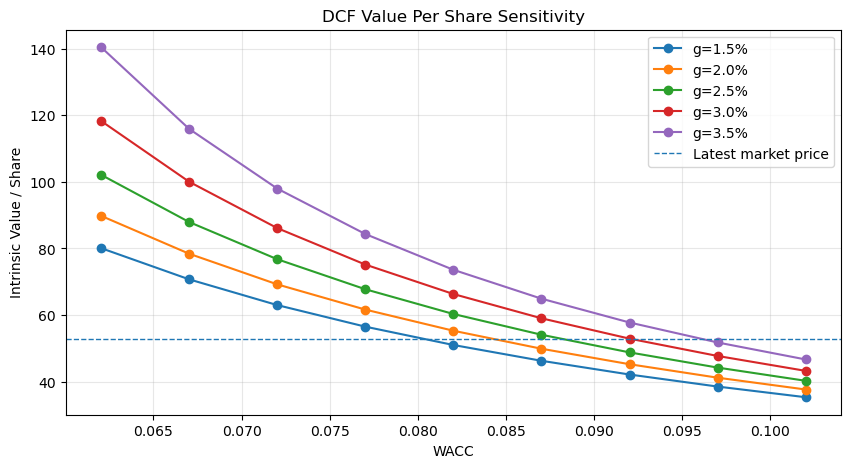

In [27]:
def dcf_value_per_share(wacc_input, terminal_growth_input, revenue_growth_input=base_revenue_growth):
    prev_revenue = last_revenue
    prev_nwc = last_nwc
    fcfs = []
    for year in range(1, projection_years + 1):
        revenue = prev_revenue * (1 + revenue_growth_input)
        ebit = revenue * ebit_margin
        nopat = ebit * (1 - tax_rate)
        da = revenue * da_percent_revenue
        capex = revenue * capex_percent_revenue
        nwc = revenue * nwc_percent_revenue
        delta_nwc = nwc - prev_nwc
        fcf = nopat + da - capex - delta_nwc
        fcfs.append(fcf)
        prev_revenue = revenue
        prev_nwc = nwc
    if wacc_input <= terminal_growth_input:
        return np.nan
    pv_fcfs = sum(fcf / ((1 + wacc_input) ** (i + 1)) for i, fcf in enumerate(fcfs))
    tv = fcfs[-1] * (1 + terminal_growth_input) / (wacc_input - terminal_growth_input)
    pv_tv = tv / ((1 + wacc_input) ** projection_years)
    ev = pv_fcfs + pv_tv
    eq = ev - latest["Total Debt"] + latest["Cash"]
    return eq / shares

wacc_range = np.arange(max(0.03, wacc - 0.02), wacc + 0.021, 0.005)
tg_range = np.arange(max(0.005, terminal_growth - 0.01), terminal_growth + 0.011, 0.005)
rg_range = np.arange(base_revenue_growth - 0.02, base_revenue_growth + 0.021, 0.005)

sensitivity_wacc_tg = pd.DataFrame(
    [[dcf_value_per_share(w, g) for w in wacc_range] for g in tg_range],
    index=[f"g={g:.1%}" for g in tg_range],
    columns=[f"WACC={w:.1%}" for w in wacc_range],
)

sensitivity_wacc_rg = pd.DataFrame(
    [[dcf_value_per_share(w, terminal_growth, revenue_growth_input=rg) for w in wacc_range] for rg in rg_range],
    index=[f"Rev g={rg:.1%}" for rg in rg_range],
    columns=[f"WACC={w:.1%}" for w in wacc_range],
)

print("Intrinsic value per share sensitivity: WACC vs. terminal growth")
display(sensitivity_wacc_tg)

print("Intrinsic value per share sensitivity: WACC vs. revenue growth")
display(sensitivity_wacc_rg)

fig, ax = plt.subplots(figsize=(10, 5))
for g in tg_range:
    vals = [dcf_value_per_share(w, g) for w in wacc_range]
    ax.plot(wacc_range, vals, marker="o", label=f"g={g:.1%}")
ax.axhline(latest["Fiscal Year-End Share Price"], linestyle="--", linewidth=1, label="Latest market price")
ax.set_title("DCF Value Per Share Sensitivity")
ax.set_xlabel("WACC")
ax.set_ylabel("Intrinsic Value / Share")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Executive Summary Tables

In [13]:
latest_ratios = ratios.loc[latest_date].dropna().to_frame("Latest")
key_metrics = pd.concat([
    return_stats,
    wacc_summary,
    dcf_assumptions,
], axis=0)

print("Latest ratio snapshot")
display(latest_ratios)

print("Selected valuation and capital-cost outputs")
display(key_metrics)

summary_text = f"""
MDLZ standalone analysis summary, using the uploaded files only:

- Latest fiscal year in statement files: {latest_date.date()}.
- Latest fiscal year-end share price used: ${latest['Fiscal Year-End Share Price']:,.2f}.
- Market beta from the FF5 regression: {market_beta:,.2f}.
- Estimated cost of equity: {cost_of_equity:,.2%}.
- Pretax cost of debt from uploaded bond yields: {pretax_cost_of_debt:,.2%}.
- Effective tax rate used in WACC: {tax_rate:,.2%}.
- Estimated WACC: {wacc:,.2%}.
- Base-case DCF intrinsic value per share: ${intrinsic_value_per_share:,.2f}.
- Market price used in DCF comparison: ${latest['Fiscal Year-End Share Price']:,.2f}.
- Implied upside/downside: {intrinsic_value_per_share / latest['Fiscal Year-End Share Price'] - 1:,.2%}.

The DCF is most sensitive to WACC, terminal growth, long-run revenue growth, EBIT margin, and the proxy FCF assumptions.
"""
print(summary_text)

Latest ratio snapshot


,Latest
Current Ratio,0.5923
Quick Ratio,0.3902
Cash Ratio,0.0972
Working Capital / Assets,-0.1247
Net Debt / Total Capital,0.4248
Asset Turnover,0.5506
Receivables Turnover,7.9712
Days Sales Outstanding,45.7896
Inventory Turnover,6.6946
Days Inventory Outstanding,54.5212


Selected valuation and capital-cost outputs


,MDLZ,Estimate,Base Case
Monthly arithmetic mean,0.0077,NaN,NaN
Monthly geometric mean,0.0057,NaN,NaN
"Expected annual return, geometric",0.0707,NaN,NaN
Annualized volatility,0.2218,NaN,NaN
Monthly skewness,0.4640,NaN,NaN
Monthly excess kurtosis,10.9305,NaN,NaN
Monthly min,-0.3532,NaN,NaN
Monthly max,0.4627,NaN,NaN
Positive months,0.5333,NaN,NaN
Observations,300.0000,NaN,NaN



MDLZ standalone analysis summary, using the uploaded files only:

- Latest fiscal year in statement files: 2025-12-31.
- Latest fiscal year-end share price used: $52.88.
- Market beta from the FF5 regression: 0.72.
- Estimated cost of equity: 9.65%.
- Pretax cost of debt from uploaded bond yields: 4.99%.
- Effective tax rate used in WACC: 25.95%.
- Estimated WACC: 8.20%.
- Base-case DCF intrinsic value per share: $60.32.
- Market price used in DCF comparison: $52.88.
- Implied upside/downside: 14.07%.

The DCF is most sensitive to WACC, terminal growth, long-run revenue growth, EBIT margin, and the proxy FCF assumptions.



## Next-Step Peer Comparison Extension

When peer financials and price data are added, revise the notebook by:

1. Wrapping the data-cleaning and ratio-building code into reusable functions.
2. Creating a ticker-level panel with a `Ticker` column.
3. Calculating common ratios for all peers on the same fiscal-year basis.
4. Adding percentile ranks and peer median comparisons.
5. Adding valuation multiple comps: P/E, EV/EBITDA, EV/Sales, P/B, FCF yield.
6. Adding relative return analysis: correlations, rolling beta, drawdowns, and FF5 regressions by ticker.
7. Adding a peer WACC table if bond data or debt-cost proxies are available for each firm.


## Peer Comparison Extension

This section keeps the standalone MDLZ analysis intact and adds a full peer-comparison layer. The peer set is:

- **NSRGY** — Nestlé S.A. ADR
- **HSY** — The Hershey Company
- **KHC** — The Kraft Heinz Company
- **PEP** — PepsiCo, Inc.
- **CAG** — Conagra Brands, Inc.
- **GIS** — General Mills, Inc.

The objective is not to replace the MDLZ analysis above, but to place MDLZ in context. The code below uses the same calculation logic across all companies, so each liquidity, efficiency, profitability, leverage, valuation, return, and factor-loading statistic is produced on a comparable basis whenever the uploaded line items permit it.

**Important comparability caveat.** The uploaded files appear to be Yahoo-style financial statement exports. For ADRs and multinational companies, currency, ADR ratio, and accounting-classification issues may affect market capitalization and valuation multiples. The notebook therefore treats market multiples for the peer set as **screening estimates**, while margin, turnover, leverage, and return-statistic comparisons are generally more reliable.


In [14]:

# ---------------------------------------------------------------------
# Peer-comparison configuration
# ---------------------------------------------------------------------
PEER_TICKERS = {
    "MDLZ": "Mondelez International",
    "NSRGY": "Nestle ADR",
    "HSY": "Hershey",
    "KHC": "Kraft Heinz",
    "PEP": "PepsiCo",
    "CAG": "Conagra Brands",
    "GIS": "General Mills",
}

PEER_FILES = {
    ticker: {
        "prices": DATA_DIR / f"{ticker}.csv",
        "income_statement": DATA_DIR / f"{ticker}_annual_financials.csv",
        "balance_sheet": DATA_DIR / f"{ticker}_annual_balance-sheet.csv",
    }
    for ticker in PEER_TICKERS
}

# MDLZ has already been used above, but include it in the common peer loop.
for ticker, filemap in PEER_FILES.items():
    missing = [str(path) for path in filemap.values() if not path.exists()]
    if missing:
        print(f"Missing files for {ticker}: {missing}")
    else:
        print(f"{ticker}: files available")


def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def load_company_data(ticker):
    """Load price, income statement, and balance sheet data for one ticker."""
    filemap = PEER_FILES[ticker]
    prices_i = pd.read_csv(filemap["prices"])
    income_i = clean_statement(pd.read_csv(filemap["income_statement"]))
    balance_i = clean_statement(pd.read_csv(filemap["balance_sheet"]))

    prices_i["Date"] = pd.to_datetime(prices_i["Date"]) + pd.offsets.MonthEnd(0)
    prices_i = prices_i.set_index("Date").sort_index()
    # Some current-month exports include both the first day of the month and the current date.
    # After month-end alignment, keep the final observation for duplicate month-end labels.
    prices_i = prices_i.groupby(level=0).last().sort_index()
    prices_i["monthly_return"] = prices_i["Adj Close"].pct_change()
    prices_i["cumulative_return"] = (1 + prices_i["monthly_return"]).cumprod() - 1

    return prices_i, income_i, balance_i


def build_fundamental_panel_for_company(ticker, prices_i, income_i, balance_i):
    """Build a standardized annual fundamentals panel for one company."""
    idx = income_i.index.union(balance_i.index).sort_values()
    panel = pd.DataFrame(index=idx)

    income_cols = [
        "Total Revenue", "Cost of Revenue", "Gross Profit", "Operating Income", "EBIT", "EBITDA",
        "Net Income", "Net Income Common Stockholders", "Pretax Income", "Tax Provision",
        "Interest Expense", "Interest Expense Non Operating", "Diluted EPS", "Basic EPS",
        "Diluted Average Shares", "Basic Average Shares", "Reconciled Depreciation",
        "Depreciation Amortization Depletion", "Depreciation & amortization", "Normalized EBITDA",
    ]
    for col in income_cols:
        panel[col] = sget(income_i.reindex(idx), col)

    balance_cols = [
        "Total Assets", "Current Assets", "Cash And Cash Equivalents",
        "Cash, Cash Equivalents & Short Term Investments", "Receivables", "Accounts receivable",
        "Inventory", "Current Liabilities", "Accounts Payable", "Working Capital",
        "Total Liabilities Net Minority Interest", "Total Equity Gross Minority Interest",
        "Stockholders' Equity", "Common Stock Equity", "Total Debt", "Net Debt", "Net PPE",
        "Invested Capital", "Ordinary Shares Number", "Share Issued",
        "Long Term Debt", "Long Term Debt And Capital Lease Obligation",
        "Current Debt", "Current Debt And Capital Lease Obligation",
    ]
    for col in balance_cols:
        panel[col] = sget(balance_i.reindex(idx), col)

    panel["Ticker"] = ticker
    panel["Company"] = PEER_TICKERS[ticker]

    panel["Cash"] = (
        panel["Cash And Cash Equivalents"]
        .combine_first(panel["Cash, Cash Equivalents & Short Term Investments"])
    )
    panel["Receivables Used"] = panel["Receivables"].combine_first(panel["Accounts receivable"])
    panel["Net Income Used"] = panel["Net Income Common Stockholders"].combine_first(panel["Net Income"])
    panel["Interest Expense Used"] = panel["Interest Expense"].combine_first(panel["Interest Expense Non Operating"]).abs()
    panel["Equity Used"] = (
        panel["Common Stock Equity"]
        .combine_first(panel["Stockholders' Equity"])
        .combine_first(panel["Total Equity Gross Minority Interest"])
    )
    panel["Shares Used"] = (
        panel["Ordinary Shares Number"]
        .combine_first(panel["Diluted Average Shares"])
        .combine_first(panel["Basic Average Shares"])
        .combine_first(panel["Share Issued"])
    )
    panel["Debt Used"] = (
        panel["Total Debt"]
        .combine_first(panel["Long Term Debt And Capital Lease Obligation"].fillna(0) + panel["Current Debt And Capital Lease Obligation"].fillna(0))
        .combine_first(panel["Long Term Debt"].fillna(0) + panel["Current Debt"].fillna(0))
    )
    panel["Net Debt Used"] = panel["Net Debt"].combine_first(panel["Debt Used"] - panel["Cash"])

    # Averages for turnover and return ratios.
    for col in ["Total Assets", "Receivables Used", "Inventory", "Accounts Payable", "Net PPE", "Working Capital", "Equity Used", "Invested Capital", "Debt Used"]:
        panel[f"Avg {col}"] = (panel[col] + panel[col].shift(1)) / 2

    # Operating cash-flow data were not supplied. Use a transparent proxy matching the standalone MDLZ section.
    panel["D&A"] = (
        panel["Reconciled Depreciation"]
        .combine_first(panel["Depreciation Amortization Depletion"])
        .combine_first(panel["Depreciation & amortization"])
    )
    panel["NWC"] = panel["Current Assets"] - panel["Current Liabilities"]
    panel["Change NWC"] = panel["NWC"].diff()
    panel["Proxy CAPEX"] = panel["Net PPE"].diff() + panel["D&A"]

    panel["Tax Rate Effective"] = safe_divide(panel["Tax Provision"], panel["Pretax Income"]).replace([np.inf, -np.inf], np.nan)
    panel["Tax Rate Effective"] = panel["Tax Rate Effective"].clip(lower=0, upper=0.60)
    panel["NOPAT"] = panel["EBIT"] * (1 - panel["Tax Rate Effective"])
    panel["Proxy FCF"] = panel["NOPAT"] + panel["D&A"] - panel["Proxy CAPEX"] - panel["Change NWC"]

    annual_price = prices_i["Adj Close"].resample("YE").last()
    panel["Fiscal Year-End Share Price"] = annual_price.reindex(panel.index)
    panel["Market Capitalization"] = panel["Fiscal Year-End Share Price"] * panel["Shares Used"]
    panel["Enterprise Value"] = panel["Market Capitalization"] + panel["Debt Used"] - panel["Cash"]

    return panel


def calculate_company_ratios(panel):
    """Calculate a broad ratio panel for one company."""
    r = pd.DataFrame(index=panel.index)

    # Liquidity
    r["Current Ratio"] = safe_divide(panel["Current Assets"], panel["Current Liabilities"])
    r["Quick Ratio"] = safe_divide(panel["Current Assets"] - panel["Inventory"], panel["Current Liabilities"])
    r["Cash Ratio"] = safe_divide(panel["Cash"], panel["Current Liabilities"])
    r["Working Capital / Assets"] = safe_divide(panel["Working Capital"], panel["Total Assets"])
    r["Current Liabilities / Assets"] = safe_divide(panel["Current Liabilities"], panel["Total Assets"])

    # Asset efficiency
    r["Asset Turnover"] = safe_divide(panel["Total Revenue"], panel["Avg Total Assets"])
    r["Receivables Turnover"] = safe_divide(panel["Total Revenue"], panel["Avg Receivables Used"])
    r["Days Sales Outstanding"] = 365 / r["Receivables Turnover"]
    r["Inventory Turnover"] = safe_divide(panel["Cost of Revenue"], panel["Avg Inventory"])
    r["Days Inventory Outstanding"] = 365 / r["Inventory Turnover"]
    r["Payables Turnover"] = safe_divide(panel["Cost of Revenue"], panel["Avg Accounts Payable"])
    r["Days Payables Outstanding"] = 365 / r["Payables Turnover"]
    r["Cash Conversion Cycle"] = r["Days Sales Outstanding"] + r["Days Inventory Outstanding"] - r["Days Payables Outstanding"]
    r["PPE Turnover"] = safe_divide(panel["Total Revenue"], panel["Avg Net PPE"])
    r["Working Capital Turnover"] = safe_divide(panel["Total Revenue"], panel["Avg Working Capital"])

    # Profitability
    r["Gross Margin"] = safe_divide(panel["Gross Profit"], panel["Total Revenue"])
    r["Operating Margin"] = safe_divide(panel["Operating Income"], panel["Total Revenue"])
    r["EBIT Margin"] = safe_divide(panel["EBIT"], panel["Total Revenue"])
    r["EBITDA Margin"] = safe_divide(panel["EBITDA"], panel["Total Revenue"])
    r["Net Margin"] = safe_divide(panel["Net Income Used"], panel["Total Revenue"])
    r["ROA"] = safe_divide(panel["Net Income Used"], panel["Avg Total Assets"])
    r["ROE"] = safe_divide(panel["Net Income Used"], panel["Avg Equity Used"])
    r["ROIC"] = safe_divide(panel["NOPAT"], panel["Avg Invested Capital"])
    r["Effective Tax Rate"] = panel["Tax Rate Effective"]
    r["FCF Margin"] = safe_divide(panel["Proxy FCF"], panel["Total Revenue"])

    # Leverage and coverage
    r["Debt / Assets"] = safe_divide(panel["Debt Used"], panel["Total Assets"])
    r["Debt / Equity"] = safe_divide(panel["Debt Used"], panel["Equity Used"])
    r["Liabilities / Assets"] = safe_divide(panel["Total Liabilities Net Minority Interest"], panel["Total Assets"])
    r["Equity Multiplier"] = safe_divide(panel["Total Assets"], panel["Equity Used"])
    r["Debt / Capital"] = safe_divide(panel["Debt Used"], panel["Debt Used"] + panel["Equity Used"])
    r["Net Debt / Total Capital"] = safe_divide(panel["Net Debt Used"], panel["Net Debt Used"] + panel["Equity Used"])
    r["Net Debt / EBITDA"] = safe_divide(panel["Net Debt Used"], panel["EBITDA"])
    r["EBITDA / Interest"] = safe_divide(panel["EBITDA"], panel["Interest Expense Used"])
    r["EBIT / Interest"] = safe_divide(panel["EBIT"], panel["Interest Expense Used"])

    # Market valuation
    r["P/E"] = safe_divide(panel["Market Capitalization"], panel["Net Income Used"])
    r["P/S"] = safe_divide(panel["Market Capitalization"], panel["Total Revenue"])
    r["P/B"] = safe_divide(panel["Market Capitalization"], panel["Equity Used"])
    r["EV / EBITDA"] = safe_divide(panel["Enterprise Value"], panel["EBITDA"])
    r["EV / EBIT"] = safe_divide(panel["Enterprise Value"], panel["EBIT"])
    r["EV / Sales"] = safe_divide(panel["Enterprise Value"], panel["Total Revenue"])
    r["FCF Yield"] = safe_divide(panel["Proxy FCF"], panel["Market Capitalization"])
    r["Earnings Yield"] = safe_divide(panel["Net Income Used"], panel["Market Capitalization"])
    r["Book-to-Market"] = safe_divide(panel["Equity Used"], panel["Market Capitalization"])

    return r.replace([np.inf, -np.inf], np.nan)


# Load all companies and build common panels.
peer_prices = {}
peer_income = {}
peer_balance = {}
peer_fundamentals = {}
peer_ratios = {}

for ticker in PEER_TICKERS:
    p_i, is_i, bs_i = load_company_data(ticker)
    peer_prices[ticker] = p_i
    peer_income[ticker] = is_i
    peer_balance[ticker] = bs_i
    peer_fundamentals[ticker] = build_fundamental_panel_for_company(ticker, p_i, is_i, bs_i)
    peer_ratios[ticker] = calculate_company_ratios(peer_fundamentals[ticker])

print("Loaded peer panels:")
display(pd.DataFrame({
    "Company": PEER_TICKERS,
    "Price start": {t: peer_prices[t].index.min().date() for t in PEER_TICKERS},
    "Price end": {t: peer_prices[t].index.max().date() for t in PEER_TICKERS},
    "Financial statement start": {t: peer_fundamentals[t].index.min().date() for t in PEER_TICKERS},
    "Financial statement end": {t: peer_fundamentals[t].index.max().date() for t in PEER_TICKERS},
}))


MDLZ: files available
NSRGY: files available
HSY: files available
KHC: files available
PEP: files available
CAG: files available
GIS: files available


Loaded peer panels:


,Company,Price start,Price end,Financial statement start,Financial statement end
MDLZ,Mondelez International,2001-06-30,2026-05-31,1998-12-31,2025-12-31
NSRGY,Nestle ADR,1996-11-30,2026-05-31,1998-12-31,2025-12-31
HSY,Hershey,1985-01-31,2026-05-31,1985-12-31,2025-12-31
KHC,Kraft Heinz,2015-07-31,2026-05-31,2010-12-31,2025-12-31
PEP,PepsiCo,1985-01-31,2026-05-31,1985-12-31,2025-12-31
CAG,Conagra Brands,1985-01-31,2026-05-31,1986-05-31,2025-05-31
GIS,General Mills,1985-01-31,2026-05-31,1986-05-31,2025-05-31


In [15]:

# ---------------------------------------------------------------------
# Latest peer ratio comparisons
# ---------------------------------------------------------------------
SELECTED_PEER_RATIOS = [
    "Current Ratio", "Quick Ratio", "Cash Ratio",
    "Asset Turnover", "Inventory Turnover", "Days Inventory Outstanding", "Cash Conversion Cycle",
    "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin", "ROA", "ROE", "ROIC", "FCF Margin",
    "Debt / Assets", "Debt / Equity", "Debt / Capital", "Net Debt / EBITDA", "EBIT / Interest",
    "P/E", "P/S", "P/B", "EV / EBITDA", "EV / Sales", "FCF Yield", "Earnings Yield",
]

def latest_valid_ratio_row(ticker):
    r = peer_ratios[ticker][SELECTED_PEER_RATIOS].dropna(how="all")
    return r.iloc[-1].rename(ticker)

latest_peer_ratios = pd.DataFrame([latest_valid_ratio_row(ticker) for ticker in PEER_TICKERS])
latest_peer_ratios.index.name = "Ticker"

# Attach latest year and company name.
latest_year = {
    ticker: peer_ratios[ticker][SELECTED_PEER_RATIOS].dropna(how="all").index[-1].year
    for ticker in PEER_TICKERS
}
latest_peer_ratios.insert(0, "Company", pd.Series(PEER_TICKERS))
latest_peer_ratios.insert(1, "Latest Year", pd.Series(latest_year))

print("Latest available peer-ratio comparison:")
display(latest_peer_ratios)

peer_median = latest_peer_ratios.drop(columns=["Company", "Latest Year"]).drop(index="MDLZ").median(numeric_only=True)
mdlz_latest = latest_peer_ratios.drop(columns=["Company", "Latest Year"]).loc["MDLZ"]
mdlz_vs_median = pd.DataFrame({
    "MDLZ": mdlz_latest,
    "Peer Median ex-MDLZ": peer_median,
    "MDLZ minus Peer Median": mdlz_latest - peer_median,
    "MDLZ / Peer Median - 1": mdlz_latest / peer_median - 1,
}).replace([np.inf, -np.inf], np.nan)

print("MDLZ versus peer median, excluding MDLZ from the peer median:")
display(mdlz_vs_median)

# Directional scorecard. These are heuristic diagnostics, not investment recommendations.
higher_is_better = [
    "Current Ratio", "Quick Ratio", "Cash Ratio", "Asset Turnover", "Inventory Turnover",
    "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin", "ROA", "ROE", "ROIC",
    "FCF Margin", "EBIT / Interest", "FCF Yield", "Earnings Yield",
]
lower_is_better = [
    "Days Inventory Outstanding", "Cash Conversion Cycle", "Debt / Assets", "Debt / Equity",
    "Debt / Capital", "Net Debt / EBITDA", "P/E", "P/S", "P/B", "EV / EBITDA", "EV / Sales",
]

score_rows = []
raw_latest = latest_peer_ratios.drop(columns=["Company", "Latest Year"])
for metric in higher_is_better + lower_is_better:
    vals = raw_latest[metric].dropna()
    if "MDLZ" not in vals.index or len(vals) < 2:
        continue
    ascending = metric in lower_is_better
    rank = vals.rank(ascending=ascending, method="min").loc["MDLZ"]
    percentile = vals.rank(pct=True, ascending=not ascending).loc["MDLZ"]
    score_rows.append({
        "Metric": metric,
        "Better Direction": "Higher" if metric in higher_is_better else "Lower",
        "MDLZ Value": vals.loc["MDLZ"],
        "Peer Median ex-MDLZ": peer_median.get(metric, np.nan),
        "MDLZ Rank": int(rank),
        "Number of Firms": len(vals),
        "Approx Percentile": percentile,
    })

mdlz_scorecard = pd.DataFrame(score_rows).set_index("Metric")
print("MDLZ directional scorecard against the uploaded peer set:")
display(mdlz_scorecard.sort_values("Approx Percentile", ascending=False))


Latest available peer-ratio comparison:


,Company,Latest Year,Current Ratio,Quick Ratio,Cash Ratio,Asset Turnover,Inventory Turnover,Days Inventory Outstanding,Cash Conversion Cycle,Gross Margin,Operating Margin,EBITDA Margin,Net Margin,ROA,ROE,ROIC,FCF Margin,Debt / Assets,Debt / Equity,Debt / Capital,Net Debt / EBITDA,EBIT / Interest,P/E,P/S,P/B,EV / EBITDA,EV / Sales,FCF Yield,Earnings Yield
Ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MDLZ,Mondelez International,2025,0.5923,0.3902,0.0972,0.5506,6.6946,54.5212,-29.0961,0.2838,0.0939,0.1290,0.0636,0.0350,0.0929,0.0583,0.1072,0.3050,0.8439,0.4577,3.8383,6.0317,27.6504,1.7586,2.6229,17.5921,2.2693,0.0610,0.0362
NSRGY,Nestle ADR,2025,0.7856,0.4707,0.1052,0.6748,3.7352,97.7189,NaN,0.4583,0.1555,0.1803,0.1005,0.0678,0.2629,0.2761,0.1301,0.4550,1.7632,0.6381,3.3055,6.8974,27.0166,2.7150,7.4380,18.3633,3.3111,0.0479,0.0370
HSY,Hershey,2025,1.1916,0.7170,0.3074,0.8762,5.7912,63.0268,48.4066,0.3355,0.1250,0.1661,0.0755,0.0662,0.1889,0.1062,0.0206,0.4176,1.2376,0.5531,2.2668,6.4011,41.5189,3.1363,7.9090,21.3540,3.5479,0.0066,0.0241
KHC,Kraft Heinz,2025,1.1537,0.7929,0.2979,0.2933,5.0842,71.7909,10.7734,0.3331,0.1859,-0.1415,-0.2344,-0.0687,-0.1287,-0.0682,-0.2250,0.2594,0.5093,0.3374,-5.2703,-4.7497,-4.8289,1.1318,0.6776,-13.2674,1.8777,-0.1988,-0.2071
PEP,PepsiCo,2025,0.8530,0.6746,0.2795,0.9081,7.7242,47.2544,-6.5112,0.5415,0.1436,0.1655,0.0877,0.0797,0.4286,0.1395,0.0644,0.4646,2.4454,0.7098,2.5750,10.1383,23.3761,2.0508,9.4393,15.0139,2.4845,0.0314,0.0428
CAG,Conagra Brands,2025,0.7114,0.2369,0.0158,0.5557,4.2728,85.4237,45.8549,0.2586,0.1263,0.1693,0.0992,0.0551,0.1327,0.0927,0.2333,0.3854,0.9032,0.4746,4.0698,3.7581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GIS,General Mills,2025,0.6714,0.4283,0.0463,0.6039,6.6966,54.5056,-23.8305,0.3455,0.1687,0.2013,0.1172,0.0708,0.2457,0.1163,0.1553,0.4625,1.6628,0.6245,3.7001,6.1658,NaN,NaN,NaN,NaN,NaN,NaN,NaN


MDLZ versus peer median, excluding MDLZ from the peer median:


,MDLZ,Peer Median ex-MDLZ,MDLZ minus Peer Median,MDLZ / Peer Median - 1
Current Ratio,0.5923,0.8193,-0.2270,-0.2770
Quick Ratio,0.3902,0.5727,-0.1825,-0.3186
Cash Ratio,0.0972,0.1923,-0.0952,-0.4947
Asset Turnover,0.5506,0.6393,-0.0887,-0.1388
Inventory Turnover,6.6946,5.4377,1.2569,0.2312
Days Inventory Outstanding,54.5212,67.4088,-12.8876,-0.1912
Cash Conversion Cycle,-29.0961,10.7734,-39.8695,-3.7007
Gross Margin,0.2838,0.3405,-0.0567,-0.1667
Operating Margin,0.0939,0.1496,-0.0557,-0.3720
EBITDA Margin,0.1290,0.1677,-0.0387,-0.2308


MDLZ directional scorecard against the uploaded peer set:


,Better Direction,MDLZ Value,Peer Median ex-MDLZ,MDLZ Rank,Number of Firms,Approx Percentile
Metric,,,,,,
FCF Yield,Higher,0.0610,0.0190,1,5,1.0000
Cash Conversion Cycle,Lower,-29.0961,10.7734,1,6,1.0000
Debt / Assets,Lower,0.3050,0.4363,2,7,0.8571
Debt / Equity,Lower,0.8439,1.4502,2,7,0.8571
Debt / Capital,Lower,0.4577,0.5888,2,7,0.8571
P/B,Lower,2.6229,7.6735,2,5,0.8000
P/S,Lower,1.7586,2.3829,2,5,0.8000
EV / Sales,Lower,2.2693,2.8978,2,5,0.8000
Inventory Turnover,Higher,6.6946,5.4377,3,7,0.7143


Peer monthly return statistics:


,Company,Start,End,Months,Annualized Return,Annualized Volatility,Monthly Mean,Monthly Std Dev,Monthly Skewness,Monthly Kurtosis,Worst Month,Best Month,Cumulative Return
Ticker,,,,,,,,,,,,,
MDLZ,Mondelez International,2001-07-31,2026-05-31,299,0.0709,0.2221,0.0078,0.0641,0.4621,10.8858,-0.3532,0.4627,4.5127
NSRGY,Nestle ADR,1996-12-31,2026-05-31,354,0.1034,0.1749,0.0095,0.0505,-0.0613,0.5124,-0.1442,0.1834,17.2271
HSY,Hershey,1985-02-28,2026-05-31,496,0.1298,0.2206,0.0122,0.0637,0.1678,1.7934,-0.2491,0.2760,154.2397
KHC,Kraft Heinz,2015-08-31,2026-05-31,130,-0.0667,0.2635,-0.0028,0.0761,-0.3402,2.0324,-0.3094,0.2470,-0.5266
PEP,PepsiCo,1985-02-28,2026-05-31,496,0.1326,0.1988,0.0121,0.0574,-0.1264,2.2434,-0.2841,0.2042,170.6817
CAG,Conagra Brands,1985-02-28,2026-05-31,496,0.0745,0.2440,0.0085,0.0704,-0.4395,1.8159,-0.3395,0.2345,18.5294
GIS,General Mills,1985-02-28,2026-05-31,496,0.0947,0.1886,0.0090,0.0544,0.1118,0.4687,-0.1771,0.1975,41.0322


Peer Fama-French five-factor loadings:


,Company,alpha,Mkt-RF,SMB,HML,RMW,CMA,R-squared,Alpha annualized,Regression months
Ticker,,,,,,,,,,
MDLZ,Mondelez International,-0.0012,0.7222,-0.3480,-0.0276,0.6111,0.5456,0.2272,-0.0147,297.0000
NSRGY,Nestle ADR,0.0026,0.5358,-0.1101,-0.1342,0.2942,0.3777,0.1881,0.0309,352.0000
HSY,Hershey,0.0025,0.5241,-0.0818,-0.1637,0.6639,0.6622,0.1530,0.0296,494.0000
KHC,Kraft Heinz,-0.0117,0.5984,0.0920,0.2519,0.3761,0.6437,0.2176,-0.1403,128.0000
PEP,PepsiCo,0.0005,0.8471,-0.2175,-0.2533,0.5756,0.5530,0.3784,0.0063,494.0000
CAG,Conagra Brands,-0.0035,0.7809,-0.0887,0.0381,0.8271,0.3891,0.2455,-0.0415,494.0000
GIS,General Mills,0.0003,0.4967,-0.0444,-0.2261,0.5962,0.4621,0.1679,0.0032,494.0000


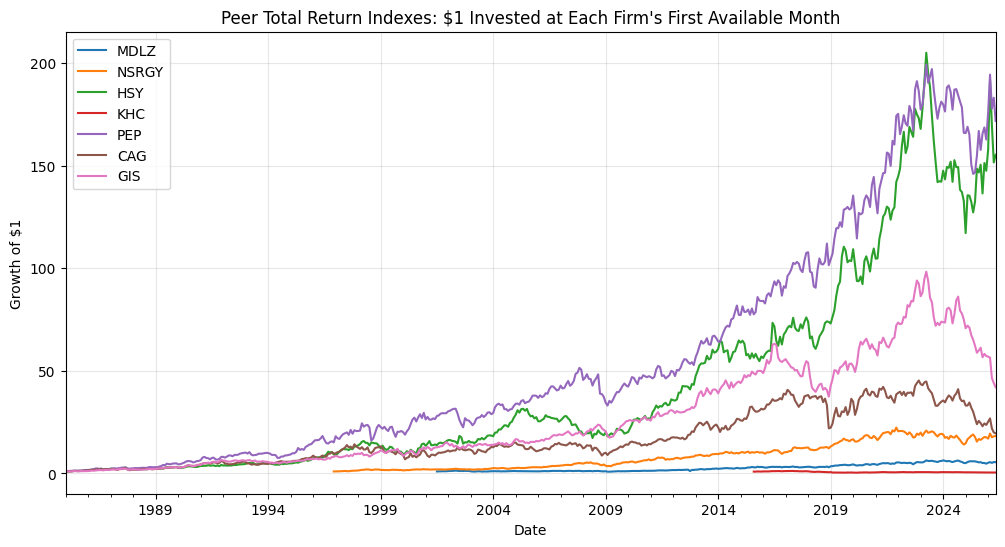

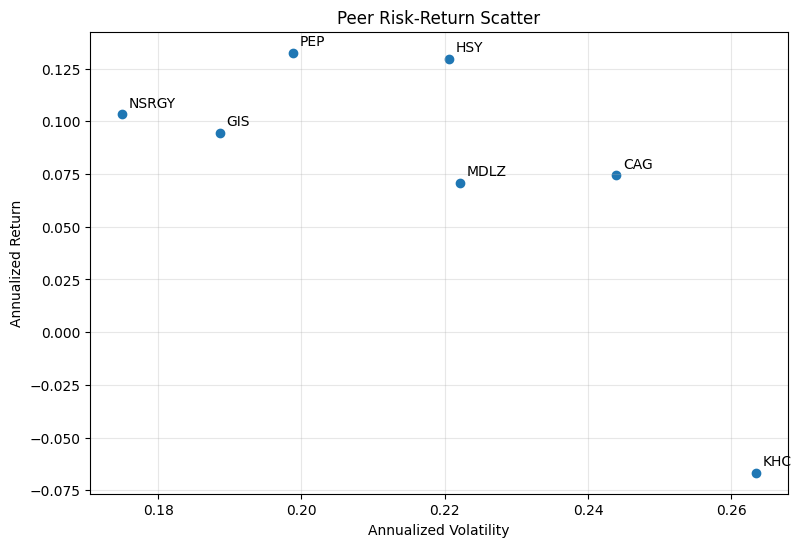

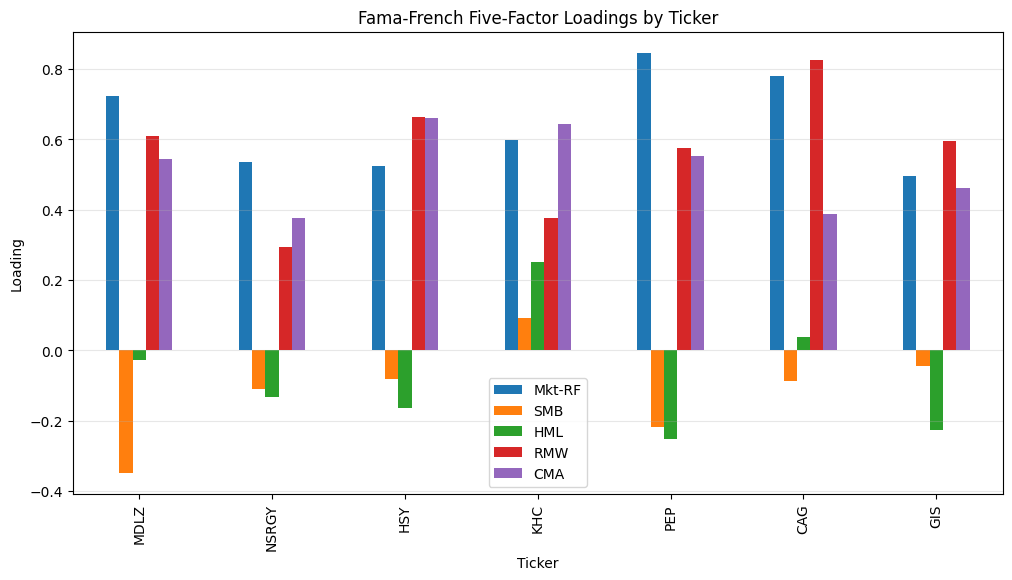

In [16]:

# ---------------------------------------------------------------------
# Peer market-return statistics and Fama-French five-factor loadings
# ---------------------------------------------------------------------
def return_statistics_for_ticker(ticker):
    rets = peer_prices[ticker]["monthly_return"].dropna()
    return pd.Series({
        "Start": rets.index.min(),
        "End": rets.index.max(),
        "Months": len(rets),
        "Annualized Return": annualize_return(rets),
        "Annualized Volatility": annualize_vol(rets),
        "Monthly Mean": rets.mean(),
        "Monthly Std Dev": rets.std(),
        "Monthly Skewness": rets.skew(),
        "Monthly Kurtosis": rets.kurt(),
        "Worst Month": rets.min(),
        "Best Month": rets.max(),
        "Cumulative Return": (1 + rets).prod() - 1,
    }, name=ticker)

peer_return_stats = pd.DataFrame([return_statistics_for_ticker(t) for t in PEER_TICKERS])
peer_return_stats.index.name = "Ticker"
peer_return_stats.insert(0, "Company", pd.Series(PEER_TICKERS))
print("Peer monthly return statistics:")
display(peer_return_stats)

def ff5_regression_for_ticker(ticker):
    data = peer_prices[ticker][["monthly_return"]].join(ff5, how="inner").dropna()
    data["excess_return"] = data["monthly_return"] - data["RF"]
    coeffs, resid, r2 = ols(data["excess_return"], data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
    out = coeffs["coef_monthly"].rename(ticker)
    out["R-squared"] = r2
    out["Alpha annualized"] = coeffs.loc["alpha", "coef_monthly"] * 12
    out["Regression months"] = len(data)
    return out

peer_ff5_loadings = pd.DataFrame([ff5_regression_for_ticker(t) for t in PEER_TICKERS])
peer_ff5_loadings.index.name = "Ticker"
peer_ff5_loadings.insert(0, "Company", pd.Series(PEER_TICKERS))
print("Peer Fama-French five-factor loadings:")
display(peer_ff5_loadings)

# Cumulative total-return comparison, indexed to $1 at each firm's first available month.
cum_returns = pd.concat(
    {
        ticker: (1 + peer_prices[ticker]["monthly_return"]).cumprod()
        for ticker in PEER_TICKERS
    },
    axis=1
)
fig, ax = plt.subplots(figsize=(12, 6))
cum_returns.plot(ax=ax)
ax.set_title("Peer Total Return Indexes: $1 Invested at Each Firm's First Available Month")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

# Return-risk scatter.
fig, ax = plt.subplots(figsize=(9, 6))
x = peer_return_stats["Annualized Volatility"]
y = peer_return_stats["Annualized Return"]
ax.scatter(x, y)
for ticker in peer_return_stats.index:
    ax.annotate(ticker, (x.loc[ticker], y.loc[ticker]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("Peer Risk-Return Scatter")
ax.grid(True, alpha=0.3)
plt.show()

# Factor loading comparison.
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
fig, ax = plt.subplots(figsize=(12, 6))
peer_ff5_loadings[factor_cols].plot(kind="bar", ax=ax)
ax.set_title("Fama-French Five-Factor Loadings by Ticker")
ax.set_ylabel("Loading")
ax.grid(True, axis="y", alpha=0.3)
plt.show()


Trailing peer growth comparisons:


Horizon                                     10Y CAGR  1Y CAGR  3Y CAGR  \
Ticker Company                Metric                                     
CAG    Conagra Brands         Book Equity     0.0704   0.0583   0.0055   
                              Debt Used       0.0020  -0.0443  -0.0421   
                              EBIT            0.0560   0.5055   0.0031   
                              EBITDA          0.0507   0.3581   0.0051   
                              Net Income         NaN   2.3191   0.0907   
                              Proxy FCF      -0.0071      NaN   0.4483   
                              Revenue         0.0254  -0.0364   0.0022   
                              Total Assets    0.0184   0.0034  -0.0228   
GIS    General Mills          Book Equity     0.0629  -0.0210  -0.0444   
                              Debt Used       0.0523   0.1488   0.0850   
                              EBIT            0.0493  -0.0404  -0.0198   
                              EBITDA          0.0389  -0.0383  -0.0196   
                              Net Income      0.0646  -0.0849  -0.0550   
                              Proxy FCF       0.0577   0.1323  -0.0571   
                              Revenue         0.0101  -0.0187   0.0086   
                              Total Assets    0.0424   0.0509   0.0208   
HSY    Hershey                Book Equity     0.1660  -0.0165   0.1201   
                              Debt Used       0.0902   0.0534   0.0389   
                              EBIT            0.0389  -0.4566  -0.1123   
                              EBITDA          0.0470  -0.3740  -0.0727   
                              Net Income      0.0558  -0.6024  -0.1872   
                              Proxy FCF      -0.1446  -0.8938  -0.5055   
                              Revenue         0.0470   0.0438   0.0392   
                              Total Assets    0.0990   0.0614   0.0787   
KHC    Kraft Heinz            Book Equity    -0.0320  -0.1529  -0.0505   
                              Debt Used      -0.0172   0.0679   0.0187   
                              Revenue         0.0312  -0.0350  -0.0198   
                              Total Assets   -0.0400  -0.0736  -0.0332   
MDLZ   Mondelez International Book Equity    -0.0080  -0.0406  -0.0131   
                              Debt Used       0.0354   0.1868  -0.0239   
                              EBIT           -0.0819  -0.4662  -0.0039   
                              EBITDA         -0.0616  -0.3841   0.0143   
                              Net Income     -0.1030  -0.4684  -0.0338   
                              Proxy FCF      -0.0752  -0.0407  -0.0762   
                              Revenue         0.0266   0.0575   0.0696   
                              Total Assets    0.0130   0.0437   0.0015   
NSRGY  Nestle ADR             Book Equity    -0.0622  -0.0865  -0.0789   
                              Debt Used       0.1054  -0.0898   0.0213   
                              EBIT            0.0005  -0.1662   0.0010   
                              EBITDA          0.0033  -0.1316   0.0027   
                              Net Income     -0.0004  -0.1701  -0.0086   
                              Proxy FCF      -0.0296   0.2290  -0.0046   
                              Revenue         0.0009  -0.0200  -0.0175   
                              Total Assets    0.0025  -0.0870  -0.0202   
PEP    PepsiCo                Book Equity     0.0556   0.1311   0.0597   
                              Debt Used       0.0413   0.1102   0.0805   
                              EBIT            0.0305  -0.1166  -0.0081   
                              EBITDA          0.0368  -0.0682   0.0136   
                              Net Income      0.0423  -0.1397  -0.0257   
                              Proxy FCF       0.0356  -0.3910  -0.1014   
                              Revenue         0.0407   0.0225   0.0283   
                              Total Assets    0.0442   0.0797   0.0522   

Hor

Latest scale and valuation-base comparison:


,Company,Revenue,EBITDA,Net Income,Total Assets,Debt Used,Market Capitalization,Enterprise Value
Ticker,,,,,,,,
MDLZ,Mondelez International,"38,537,000,000.0000","4,971,000,000.0000","2,451,000,000.0000","71,487,000,000.0000","21,804,000,000.0000","67,771,165,380.0697","87,450,165,380.0697"
NSRGY,Nestle ADR,"89,885,000,000.0000","16,207,000,000.0000","9,033,000,000.0000","127,151,000,000.0000","57,852,000,000.0000","244,040,864,387.6000","297,613,864,387.6000"
HSY,Hershey,"11,692,576,000.0000","1,942,715,000.0000","883,259,000.0000","13,741,297,000.0000","5,738,575,000.0000","36,671,958,892.7406","41,484,674,892.7406"
KHC,Kraft Heinz,"24,942,000,000.0000","-3,530,000,000.0000","-5,846,000,000.0000","81,786,000,000.0000","21,219,000,000.0000","28,229,794,952.8089","46,833,794,952.8089"
PEP,PepsiCo,"93,925,000,000.0000","15,543,000,000.0000","8,240,000,000.0000","107,399,000,000.0000","49,901,000,000.0000","192,618,949,079.4758","233,360,949,079.4758"
CAG,Conagra Brands,"11,612,800,000.0000","1,965,600,000.0000","1,152,400,000.0000","20,933,900,000.0000","8,067,600,000.0000",NaN,NaN
GIS,General Mills,"19,486,600,000.0000","3,922,800,000.0000","2,284,700,000.0000","33,071,100,000.0000","15,296,700,000.0000",NaN,NaN


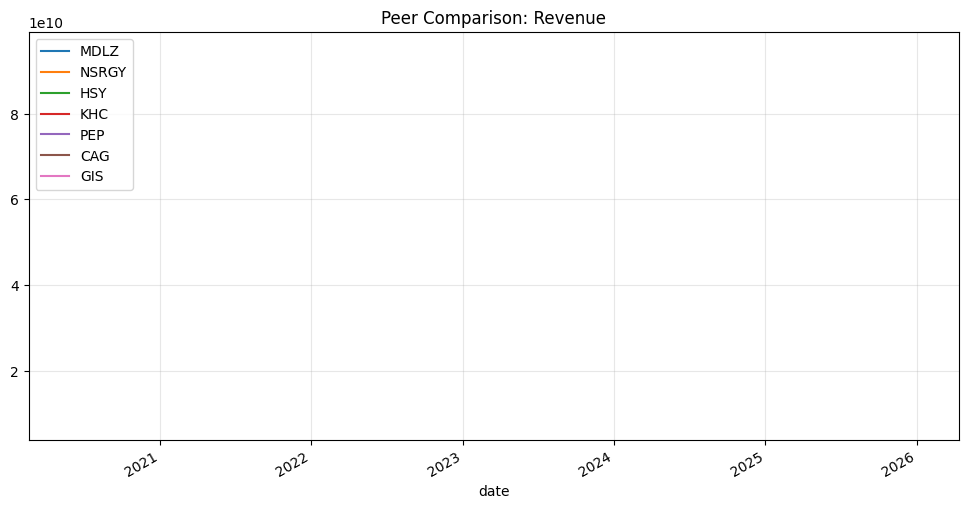

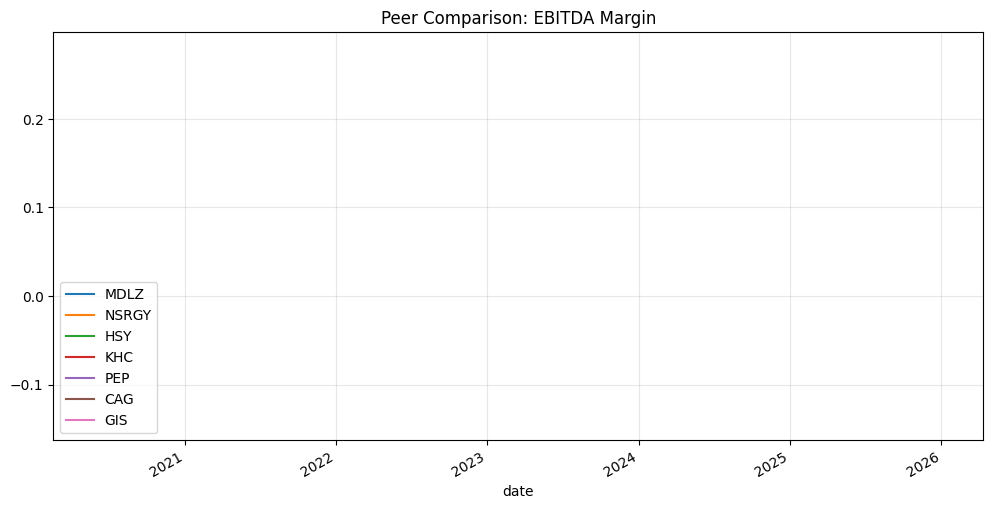

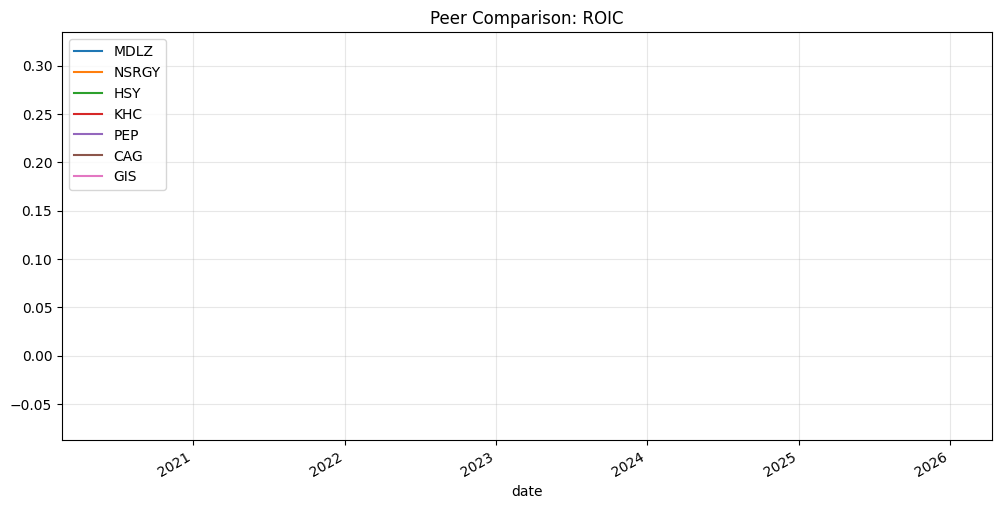

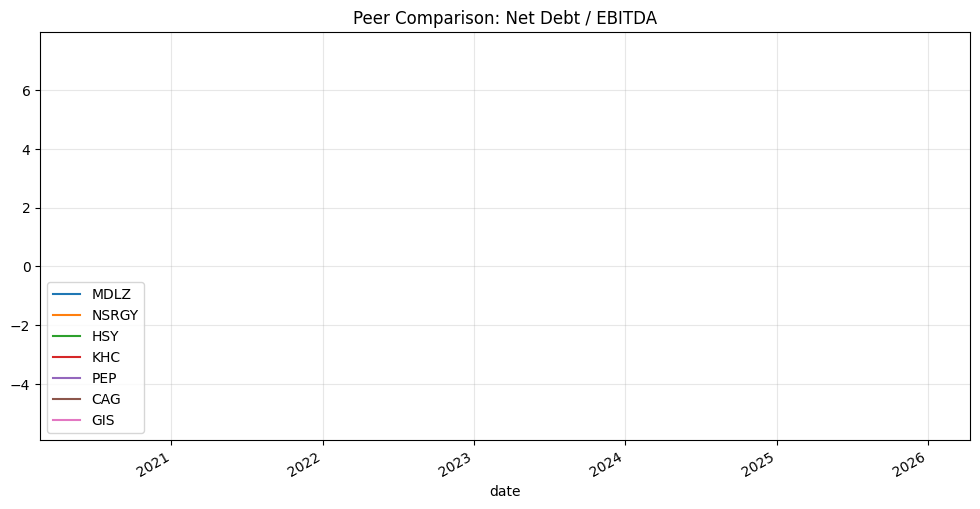

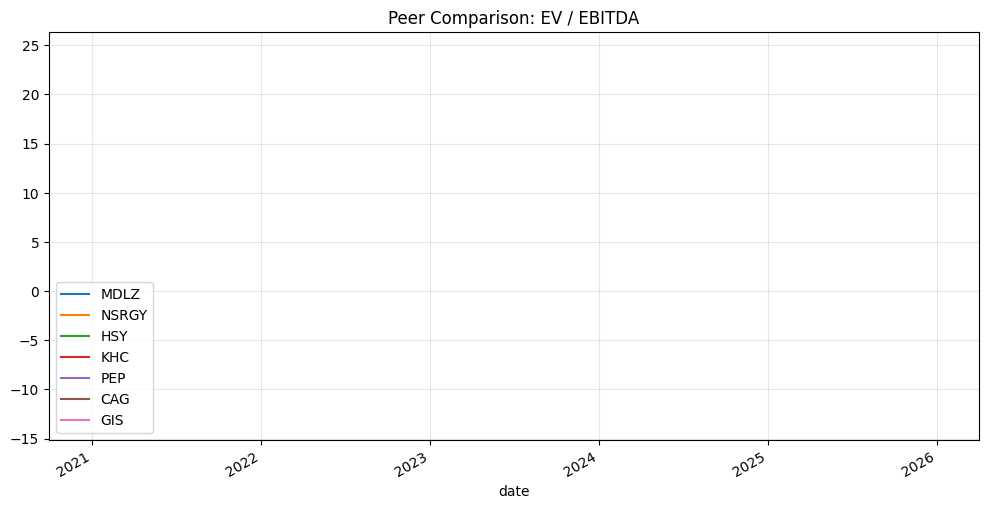

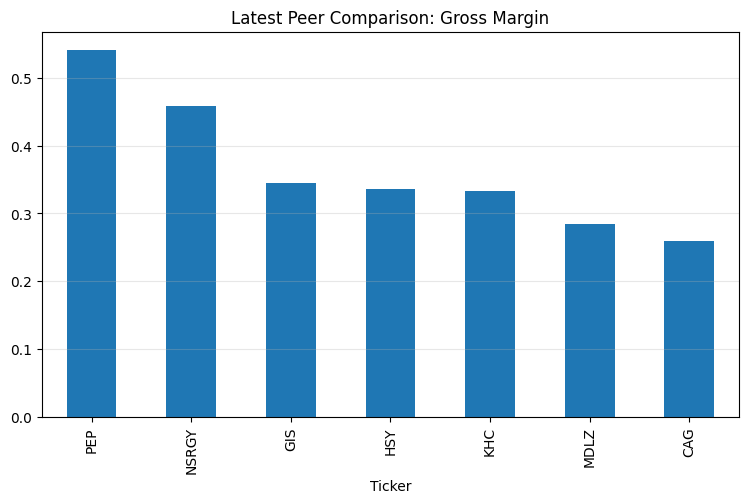

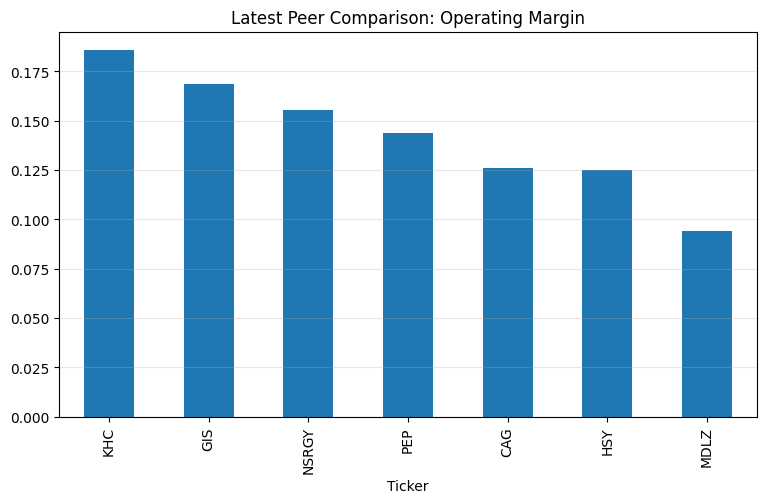

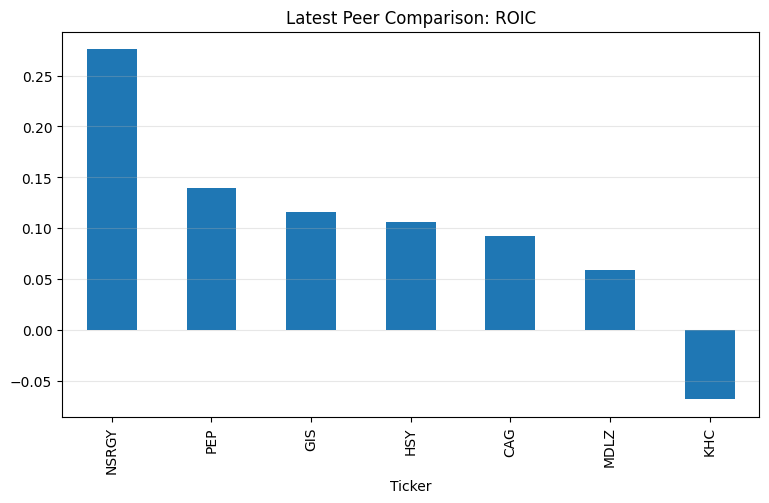

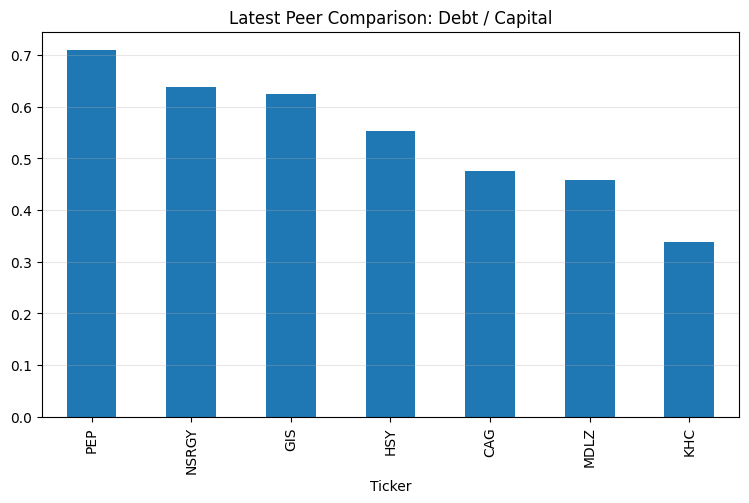

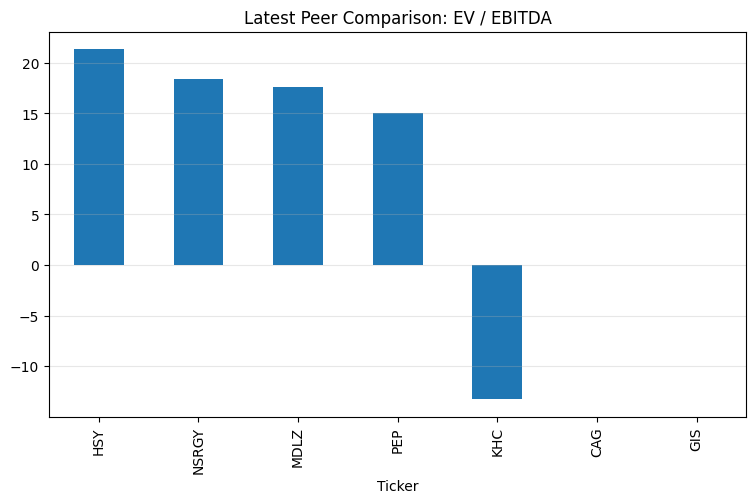

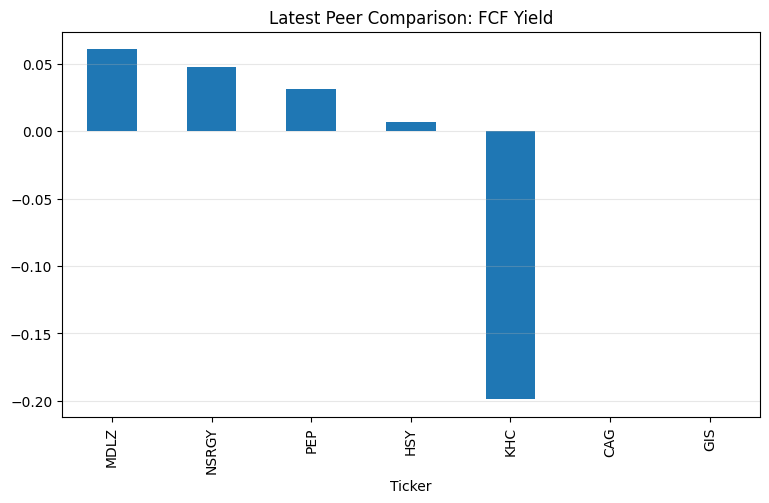

In [17]:

# ---------------------------------------------------------------------
# Peer growth comparisons
# ---------------------------------------------------------------------
def trailing_growth(series, years):
    s = series.dropna()
    if len(s) < years + 1:
        return np.nan
    s = s.iloc[-(years + 1):]
    if s.iloc[0] <= 0 or s.iloc[-1] <= 0:
        return np.nan
    return (s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1

growth_metrics = {
    "Revenue": "Total Revenue",
    "EBIT": "EBIT",
    "EBITDA": "EBITDA",
    "Net Income": "Net Income Used",
    "Proxy FCF": "Proxy FCF",
    "Total Assets": "Total Assets",
    "Debt Used": "Debt Used",
    "Book Equity": "Equity Used",
}

growth_rows = []
for ticker in PEER_TICKERS:
    panel = peer_fundamentals[ticker]
    for label, col in growth_metrics.items():
        for years in [1, 3, 5, 10]:
            growth_rows.append({
                "Ticker": ticker,
                "Company": PEER_TICKERS[ticker],
                "Metric": label,
                "Horizon": f"{years}Y CAGR",
                "Growth": trailing_growth(panel[col], years),
            })

peer_growth = pd.DataFrame(growth_rows)
peer_growth_pivot = peer_growth.pivot_table(
    index=["Ticker", "Company", "Metric"],
    columns="Horizon",
    values="Growth",
    aggfunc="first"
).sort_index()

print("Trailing peer growth comparisons:")
display(peer_growth_pivot)

# Latest size and profitability comparison.
def last_or_nan(series):
    s = series.dropna()
    return s.iloc[-1] if len(s) else np.nan

latest_size_profit = pd.DataFrame({
    ticker: {
        "Company": PEER_TICKERS[ticker],
        "Revenue": last_or_nan(peer_fundamentals[ticker]["Total Revenue"]),
        "EBITDA": last_or_nan(peer_fundamentals[ticker]["EBITDA"]),
        "Net Income": last_or_nan(peer_fundamentals[ticker]["Net Income Used"]),
        "Total Assets": last_or_nan(peer_fundamentals[ticker]["Total Assets"]),
        "Debt Used": last_or_nan(peer_fundamentals[ticker]["Debt Used"]),
        "Market Capitalization": last_or_nan(peer_fundamentals[ticker]["Market Capitalization"]),
        "Enterprise Value": last_or_nan(peer_fundamentals[ticker]["Enterprise Value"]),
    }
    for ticker in PEER_TICKERS
}).T
latest_size_profit.index.name = "Ticker"

print("Latest scale and valuation-base comparison:")
display(latest_size_profit)

# Revenue, margin, leverage, and valuation visual summaries.
plot_metrics = {
    "Revenue": ("Total Revenue", peer_fundamentals),
    "EBITDA Margin": ("EBITDA Margin", peer_ratios),
    "ROIC": ("ROIC", peer_ratios),
    "Net Debt / EBITDA": ("Net Debt / EBITDA", peer_ratios),
    "EV / EBITDA": ("EV / EBITDA", peer_ratios),
}

for title, (metric, source_dict) in plot_metrics.items():
    panel_plot = pd.DataFrame({ticker: source_dict[ticker][metric] for ticker in PEER_TICKERS})
    fig, ax = plt.subplots(figsize=(12, 6))
    panel_plot.tail(12).plot(ax=ax)
    ax.set_title(f"Peer Comparison: {title}")
    ax.grid(True, alpha=0.3)
    plt.show()

# Cross-sectional bar charts for latest selected metrics.
latest_bar_metrics = ["Gross Margin", "Operating Margin", "ROIC", "Debt / Capital", "EV / EBITDA", "FCF Yield"]
for metric in latest_bar_metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    raw_latest[metric].sort_values(ascending=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Latest Peer Comparison: {metric}")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


Peer WACC proxy comparison:


,Company,Market Beta,Cost of Equity,Pretax Cost of Debt Proxy,Tax Rate,Debt Weight,Equity Weight,WACC Proxy,Market Capitalization,Debt Used
Ticker,,,,,,,,,,
MDLZ,Mondelez International,0.7222,0.0855,0.0298,0.2595,0.2434,0.7566,0.0701,"67,771,165,380.0697","21,804,000,000.0000"
NSRGY,Nestle ADR,0.5358,0.0724,0.0300,0.2456,0.1916,0.8084,0.0629,"244,040,864,387.6000","57,852,000,000.0000"
HSY,Hershey,0.5241,0.0716,0.0402,0.2726,0.1353,0.8647,0.0659,"36,671,958,892.7406","5,738,575,000.0000"
KHC,Kraft Heinz,0.5984,0.0768,0.0461,0.0000,0.4291,0.5709,0.0636,"28,229,794,952.8089","21,219,000,000.0000"
PEP,PepsiCo,0.8471,0.0943,0.0236,0.1903,0.2058,0.7942,0.0788,"192,618,949,079.4758","49,901,000,000.0000"
CAG,Conagra Brands,0.7809,0.0896,0.0508,0.0032,NaN,NaN,NaN,NaN,"8,067,600,000.0000"
GIS,General Mills,0.4967,0.0697,0.0384,0.2024,NaN,NaN,NaN,NaN,"15,296,700,000.0000"


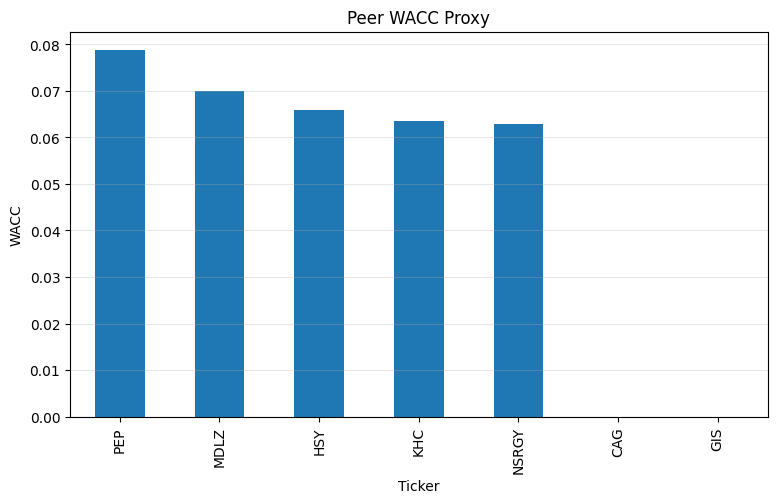

Compact peer dashboard:


,Gross Margin,Operating Margin,EBITDA Margin,ROIC,Debt / Capital,Net Debt / EBITDA,EV / EBITDA,FCF Yield,Annualized Return,Annualized Volatility,Monthly Skewness,Monthly Kurtosis,Mkt-RF,SMB,HML,RMW,CMA,R-squared,Alpha annualized,WACC Proxy,Cost of Equity,Pretax Cost of Debt Proxy
Ticker,,,,,,,,,,,,,,,,,,,,,,
MDLZ,0.2838,0.0939,0.1290,0.0583,0.4577,3.8383,17.5921,0.0610,0.0709,0.2221,0.4621,10.8858,0.7222,-0.3480,-0.0276,0.6111,0.5456,0.2272,-0.0147,0.0701,0.0855,0.0298
NSRGY,0.4583,0.1555,0.1803,0.2761,0.6381,3.3055,18.3633,0.0479,0.1034,0.1749,-0.0613,0.5124,0.5358,-0.1101,-0.1342,0.2942,0.3777,0.1881,0.0309,0.0629,0.0724,0.0300
HSY,0.3355,0.1250,0.1661,0.1062,0.5531,2.2668,21.3540,0.0066,0.1298,0.2206,0.1678,1.7934,0.5241,-0.0818,-0.1637,0.6639,0.6622,0.1530,0.0296,0.0659,0.0716,0.0402
KHC,0.3331,0.1859,-0.1415,-0.0682,0.3374,-5.2703,-13.2674,-0.1988,-0.0667,0.2635,-0.3402,2.0324,0.5984,0.0920,0.2519,0.3761,0.6437,0.2176,-0.1403,0.0636,0.0768,0.0461
PEP,0.5415,0.1436,0.1655,0.1395,0.7098,2.5750,15.0139,0.0314,0.1326,0.1988,-0.1264,2.2434,0.8471,-0.2175,-0.2533,0.5756,0.5530,0.3784,0.0063,0.0788,0.0943,0.0236
CAG,0.2586,0.1263,0.1693,0.0927,0.4746,4.0698,NaN,NaN,0.0745,0.2440,-0.4395,1.8159,0.7809,-0.0887,0.0381,0.8271,0.3891,0.2455,-0.0415,NaN,0.0896,0.0508
GIS,0.3455,0.1687,0.2013,0.1163,0.6245,3.7001,NaN,NaN,0.0947,0.1886,0.1118,0.4687,0.4967,-0.0444,-0.2261,0.5962,0.4621,0.1679,0.0032,NaN,0.0697,0.0384


Saved JSON outputs for peer tables in the working directory.


In [18]:

# ---------------------------------------------------------------------
# Peer WACC proxy and valuation-context diagnostics
# ---------------------------------------------------------------------
# MDLZ above uses uploaded bond yields to estimate the pretax cost of debt.
# The peer files do not include peer-level bond sheets, so this section uses a transparent proxy:
#   - Cost of equity: CAPM with the Fama-French market beta from each company's monthly return regression.
#   - Pretax cost of debt: interest expense / average debt, clipped to a plausible range.
#   - Tax rate: latest effective tax rate, clipped to the same range used above.
#   - Capital weights: market equity and book debt.

PEER_WACC_ASSUMPTIONS = {
    "normalized_risk_free_rate": float(latest_monthly_rf * 12) if not np.isnan(latest_monthly_rf) else 0.04,
    "equity_risk_premium": ASSUMPTIONS["equity_risk_premium_override"] if ASSUMPTIONS["equity_risk_premium_override"] is not None else float(ff5["Mkt-RF"].dropna().mean() * 12),
    "min_pretax_cost_of_debt": 0.01,
    "max_pretax_cost_of_debt": 0.12,
    "default_tax_rate": ASSUMPTIONS["marginal_tax_rate_override"] if ASSUMPTIONS["marginal_tax_rate_override"] is not None else 0.21,
}

def peer_wacc_proxy(ticker):
    panel = peer_fundamentals[ticker].dropna(how="all")
    latest_panel = panel.iloc[-1]
    avg_debt = panel["Avg Debt Used"].dropna().iloc[-1] if panel["Avg Debt Used"].dropna().shape[0] else latest_panel["Debt Used"]
    pretax_cod = latest_panel["Interest Expense Used"] / avg_debt if avg_debt and avg_debt > 0 else np.nan
    pretax_cod = np.clip(pretax_cod, PEER_WACC_ASSUMPTIONS["min_pretax_cost_of_debt"], PEER_WACC_ASSUMPTIONS["max_pretax_cost_of_debt"])

    beta_mkt = peer_ff5_loadings.loc[ticker, "Mkt-RF"]
    cost_equity = PEER_WACC_ASSUMPTIONS["normalized_risk_free_rate"] + beta_mkt * PEER_WACC_ASSUMPTIONS["equity_risk_premium"]

    tax_rate_i = latest_panel["Tax Rate Effective"]
    if pd.isna(tax_rate_i):
        tax_rate_i = PEER_WACC_ASSUMPTIONS["default_tax_rate"]
    tax_rate_i = np.clip(tax_rate_i, 0.0, 0.60)

    debt_value = latest_panel["Debt Used"]
    equity_value = latest_panel["Market Capitalization"]
    total_capital = debt_value + equity_value
    debt_weight = debt_value / total_capital if total_capital and total_capital > 0 else np.nan
    equity_weight = equity_value / total_capital if total_capital and total_capital > 0 else np.nan
    wacc_i = equity_weight * cost_equity + debt_weight * pretax_cod * (1 - tax_rate_i)

    return pd.Series({
        "Company": PEER_TICKERS[ticker],
        "Market Beta": beta_mkt,
        "Cost of Equity": cost_equity,
        "Pretax Cost of Debt Proxy": pretax_cod,
        "Tax Rate": tax_rate_i,
        "Debt Weight": debt_weight,
        "Equity Weight": equity_weight,
        "WACC Proxy": wacc_i,
        "Market Capitalization": equity_value,
        "Debt Used": debt_value,
    }, name=ticker)

peer_wacc = pd.DataFrame([peer_wacc_proxy(t) for t in PEER_TICKERS])
peer_wacc.index.name = "Ticker"

print("Peer WACC proxy comparison:")
display(peer_wacc)

fig, ax = plt.subplots(figsize=(9, 5))
peer_wacc["WACC Proxy"].sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Peer WACC Proxy")
ax.set_ylabel("WACC")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

# A compact MDLZ peer-dashboard table, combining accounting, market, growth, factor, and WACC information.
dashboard_cols = [
    "Gross Margin", "Operating Margin", "EBITDA Margin", "ROIC",
    "Debt / Capital", "Net Debt / EBITDA", "EV / EBITDA", "FCF Yield",
]
peer_dashboard = raw_latest[dashboard_cols].join(
    peer_return_stats[["Annualized Return", "Annualized Volatility", "Monthly Skewness", "Monthly Kurtosis"]]
).join(
    peer_ff5_loadings[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "R-squared", "Alpha annualized"]]
).join(
    peer_wacc[["WACC Proxy", "Cost of Equity", "Pretax Cost of Debt Proxy"]]
)

print("Compact peer dashboard:")
display(peer_dashboard)

# Export machine-readable tables for later peer-extension work.
latest_peer_ratios.to_json(DATA_DIR / "Peer_Latest_Ratio_Comparison.json", orient="table")
mdlz_vs_median.to_json(DATA_DIR / "MDLZ_vs_Peer_Median.json", orient="table")
peer_return_stats.to_json(DATA_DIR / "Peer_Return_Statistics.json", orient="table", date_format="iso")
peer_ff5_loadings.to_json(DATA_DIR / "Peer_FF5_Loadings.json", orient="table")
peer_growth_pivot.reset_index().to_json(DATA_DIR / "Peer_Growth_Comparison.json", orient="table")
peer_wacc.to_json(DATA_DIR / "Peer_WACC_Proxy.json", orient="table")
peer_dashboard.to_json(DATA_DIR / "Peer_Dashboard.json", orient="table")

print("Saved JSON outputs for peer tables in the working directory.")



## Peer-Comparison Interpretation Guide

Use the peer section as a diagnostic layer:

1. **Accounting quality and operations.** Margin, turnover, ROA, ROE, ROIC, working-capital intensity, and cash-conversion-cycle measures describe how MDLZ performs as a business relative to other packaged-food and snack companies.
2. **Balance-sheet risk.** Debt-to-capital, net-debt-to-EBITDA, and interest-coverage ratios summarize financial leverage and debt-service capacity.
3. **Market pricing.** P/E, EV/EBITDA, EV/Sales, FCF yield, and earnings yield show whether MDLZ appears expensive or cheap relative to its operating performance and growth.
4. **Return behavior.** Annualized returns, volatility, skewness, kurtosis, and Fama-French loadings show how the stock has behaved as a traded asset.
5. **WACC and valuation context.** The peer WACC table is a transparent proxy. MDLZ’s standalone WACC above is more bond-market-grounded because the MDLZ bond file was supplied. For peers, the notebook estimates cost of debt from accounting interest expense and book debt unless peer bond files are later added.

The next natural enhancement would be to add peer bond files, peer cash-flow statements, segment-level revenue detail, and analyst forecast inputs, then build a true relative-valuation and sum-of-the-parts section.



# Enhanced Peer Ratio Comparisons and Investment Interpretation

This section preserves the earlier single-company MDLZ analysis and peer-return work, but adds a more complete peer-ratio layer. The earlier notebook emphasized margins, growth, valuation, return statistics, factor loadings, WACC, and DCF. The missing or thinner parts were mostly due to data-structure problems rather than conceptual omissions: turnover, liquidity, and leverage ratios require carefully matching income-statement flow variables to balance-sheet stock variables, and the downloaded Yahoo-style statement files use fiscal year dates that differ across firms. This section standardizes those calculations across **MDLZ, NSRGY, HSY, KHC, PEP, CAG, and GIS**.

The added calculations include:

- **Liquidity:** current ratio, quick ratio, cash ratio, working capital / revenue, current liabilities / assets.
- **Activity and turnover:** asset turnover, fixed-asset turnover, receivables turnover, inventory turnover, payables turnover, working-capital turnover, DSO, DIO, DPO, and cash-conversion cycle.
- **Leverage and coverage:** debt / assets, debt / equity, liabilities / assets, debt / capital, net debt / EBITDA, equity multiplier, and interest coverage.
- **Profitability and DuPont-style quality:** gross margin, operating margin, EBIT margin, EBITDA margin, net margin, ROA, ROE, and ROIC.
- **Valuation:** P/E, P/B, EV/Sales, EV/EBITDA, and a proxy FCF yield.
- **Growth:** revenue growth, net-income growth, EBITDA growth, and proxy FCF growth.

Because these files do not include complete cash-flow statements for every company, the free-cash-flow variable below is a **proxy**, not a substitute for reported CFO minus capex. It uses NOPAT, depreciation, a gross-PPE-based capex proxy, and changes in working capital. The notebook explicitly labels it as a proxy so the user can replace it with reported cash-flow data later.


In [19]:

# Expanded peer-ratio comparison layer
# This section is self-contained. It does not remove or overwrite the earlier MDLZ analysis.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

PEER_TICKERS = ["MDLZ", "NSRGY", "HSY", "KHC", "PEP", "CAG", "GIS"]
DATA_DIR = Path("/mnt/data")

def _clean_item_name(x):
    return str(x).replace("\t", "").strip()

def _parse_number(x):
    """Parse Yahoo-style CSV values: commas, dollars, percentages, blanks, and parenthesized negatives."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in {"", "-", "nan", "None"}:
        return np.nan
    neg = s.startswith("(") and s.endswith(")")
    if neg:
        s = s[1:-1]
    s = s.replace(",", "").replace("$", "").replace("%", "")
    try:
        val = float(s)
        return -val if neg else val
    except ValueError:
        return np.nan

def load_yahoo_statement(ticker, statement_kind):
    """
    statement_kind should be "financials" or "balance-sheet".
    Returns a date-indexed statement with cleaned row names as columns.
    """
    path = DATA_DIR / f"{ticker}_annual_{statement_kind}.csv"
    raw = pd.read_csv(path)
    raw["item"] = raw["name"].map(_clean_item_name)
    date_cols = [c for c in raw.columns if re.match(r"\d{1,2}/\d{1,2}/\d{4}", str(c))]
    out = {}
    for _, row in raw.iterrows():
        out[row["item"]] = {pd.to_datetime(c): _parse_number(row[c]) for c in date_cols}
    return pd.DataFrame(out).sort_index()

def load_price_history(ticker):
    path = DATA_DIR / f"{ticker}.csv"
    px = pd.read_csv(path)
    px["Date"] = pd.to_datetime(px["Date"])
    px = px.sort_values("Date").set_index("Date")
    px["monthly_return"] = px["Adj Close"].pct_change()
    return px

def stmt_col(df, name):
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)

def avg_balance(series):
    return (series + series.shift(1)) / 2

def fiscal_date_price(price_series, fiscal_index):
    """Use the most recent available adjusted close at or before each fiscal statement date."""
    price_series = price_series.dropna().sort_index()
    out = pd.Series(index=fiscal_index, dtype=float)
    for d in fiscal_index:
        prior = price_series.loc[price_series.index <= d]
        out.loc[d] = prior.iloc[-1] if len(prior) else np.nan
    return out

def build_company_ratio_panel(ticker):
    fin = load_yahoo_statement(ticker, "financials")
    bs = load_yahoo_statement(ticker, "balance-sheet")
    idx = fin.index.union(bs.index).sort_values()
    fin = fin.reindex(idx)
    bs = bs.reindex(idx)

    prices = load_price_history(ticker)
    price = fiscal_date_price(prices["Adj Close"], idx)

    revenue = stmt_col(fin, "Total Revenue")
    cogs = stmt_col(fin, "Cost of Revenue")
    gross_profit = stmt_col(fin, "Gross Profit")
    operating_income = stmt_col(fin, "Operating Income")
    ebit = stmt_col(fin, "EBIT")
    ebitda = stmt_col(fin, "EBITDA")
    pretax_income = stmt_col(fin, "Pretax Income")
    tax_provision = stmt_col(fin, "Tax Provision")
    net_income = stmt_col(fin, "Net Income Common Stockholders")
    interest_expense = stmt_col(fin, "Interest Expense").abs().combine_first(
        stmt_col(fin, "Interest Expense Non Operating").abs()
    )
    depreciation = stmt_col(fin, "Reconciled Depreciation").combine_first(
        stmt_col(fin, "Depreciation & amortization")
    )
    shares = stmt_col(fin, "Diluted Average Shares").combine_first(
        stmt_col(bs, "Ordinary Shares Number")
    ).combine_first(stmt_col(bs, "Share Issued"))

    assets = stmt_col(bs, "Total Assets")
    current_assets = stmt_col(bs, "Current Assets")
    cash = stmt_col(bs, "Cash, Cash Equivalents & Short Term Investments").combine_first(
        stmt_col(bs, "Cash And Cash Equivalents")
    )
    receivables = stmt_col(bs, "Receivables").combine_first(stmt_col(bs, "Accounts receivable"))
    inventory = stmt_col(bs, "Inventory")
    net_ppe = stmt_col(bs, "Net PPE")
    gross_ppe = stmt_col(bs, "Gross PPE")
    current_liabilities = stmt_col(bs, "Current Liabilities")
    accounts_payable = stmt_col(bs, "Accounts Payable").combine_first(stmt_col(bs, "Payables"))
    liabilities = stmt_col(bs, "Total Liabilities Net Minority Interest")
    equity = stmt_col(bs, "Common Stock Equity").combine_first(stmt_col(bs, "Stockholders' Equity"))
    debt = stmt_col(bs, "Total Debt")
    net_debt = stmt_col(bs, "Net Debt")
    invested_capital = stmt_col(bs, "Invested Capital")
    working_capital = stmt_col(bs, "Working Capital").combine_first(current_assets - current_liabilities)

    avg_assets = avg_balance(assets)
    avg_equity = avg_balance(equity)
    avg_inventory = avg_balance(inventory)
    avg_receivables = avg_balance(receivables)
    avg_payables = avg_balance(accounts_payable)
    avg_ppe = avg_balance(net_ppe)
    avg_working_capital = avg_balance(working_capital)
    avg_invested_capital = avg_balance(invested_capital)

    tax_rate = (tax_provision / pretax_income).clip(lower=0, upper=0.60)
    nopat = ebit * (1 - tax_rate.fillna(0.21))

    # Proxy FCF: useful for cross-company screening when cash-flow statements are unavailable.
    # Replace this with reported CFO - capex if cash-flow statements are later added.
    capex_proxy = (gross_ppe - gross_ppe.shift(1) + depreciation).where(lambda x: x > 0, np.nan)
    delta_nwc = working_capital - working_capital.shift(1)
    fcf_proxy = nopat + depreciation - capex_proxy - delta_nwc

    market_cap = price * shares
    enterprise_value = market_cap + debt - cash

    r = pd.DataFrame(index=idx)
    r["Ticker"] = ticker

    # Scale variables
    r["Revenue"] = revenue
    r["Market Cap"] = market_cap
    r["Enterprise Value"] = enterprise_value
    r["FCF Proxy"] = fcf_proxy

    # Profitability
    r["Gross Margin"] = gross_profit / revenue
    r["Operating Margin"] = operating_income / revenue
    r["EBIT Margin"] = ebit / revenue
    r["EBITDA Margin"] = ebitda / revenue
    r["Pretax Margin"] = pretax_income / revenue
    r["Net Margin"] = net_income / revenue
    r["ROA"] = net_income / avg_assets
    r["ROE"] = net_income / avg_equity
    r["ROIC"] = nopat / avg_invested_capital

    # Turnover / activity
    r["Asset Turnover"] = revenue / avg_assets
    r["Fixed Asset Turnover"] = revenue / avg_ppe
    r["Receivables Turnover"] = revenue / avg_receivables
    r["Inventory Turnover"] = cogs / avg_inventory
    r["Payables Turnover"] = cogs / avg_payables
    r["Working Capital Turnover"] = revenue / avg_working_capital
    r["Days Sales Outstanding"] = 365 / r["Receivables Turnover"]
    r["Days Inventory Outstanding"] = 365 / r["Inventory Turnover"]
    r["Days Payable Outstanding"] = 365 / r["Payables Turnover"]
    r["Cash Conversion Cycle"] = (
        r["Days Sales Outstanding"] + r["Days Inventory Outstanding"] - r["Days Payable Outstanding"]
    )

    # Liquidity
    r["Current Ratio"] = current_assets / current_liabilities
    r["Quick Ratio"] = (cash + receivables) / current_liabilities
    r["Cash Ratio"] = cash / current_liabilities
    r["Working Capital / Revenue"] = working_capital / revenue
    r["Current Liabilities / Assets"] = current_liabilities / assets

    # Leverage and coverage
    r["Debt / Assets"] = debt / assets
    r["Debt / Equity"] = debt / equity
    r["Liabilities / Assets"] = liabilities / assets
    r["Debt / Capital"] = debt / (debt + equity)
    r["Net Debt / EBITDA"] = net_debt / ebitda
    r["Equity Multiplier"] = avg_assets / avg_equity
    r["Interest Coverage"] = ebit / interest_expense

    # Valuation
    r["P/E"] = market_cap / net_income
    r["P/B"] = market_cap / equity
    r["EV/Sales"] = enterprise_value / revenue
    r["EV/EBITDA"] = enterprise_value / ebitda
    r["FCF Yield"] = fcf_proxy / market_cap

    # Growth
    r["Revenue Growth"] = revenue.pct_change(fill_method=None)
    r["Net Income Growth"] = net_income.pct_change(fill_method=None)
    r["EBITDA Growth"] = ebitda.pct_change(fill_method=None)
    r["FCF Proxy Growth"] = fcf_proxy.pct_change(fill_method=None)

    return r

expanded_ratios = pd.concat([build_company_ratio_panel(t) for t in PEER_TICKERS])
expanded_ratios = expanded_ratios.reset_index(names="Fiscal Date").sort_values(["Ticker", "Fiscal Date"])

latest_expanded = (
    expanded_ratios.dropna(subset=["Revenue"])
    .sort_values(["Ticker", "Fiscal Date"])
    .groupby("Ticker", as_index=False)
    .tail(1)
    .set_index("Ticker")
)

three_year_avg_expanded = (
    expanded_ratios.dropna(subset=["Revenue"])
    .sort_values(["Ticker", "Fiscal Date"])
    .groupby("Ticker")
    .tail(3)
    .groupby("Ticker")
    .mean(numeric_only=True)
)

expanded_ratios.to_csv(DATA_DIR / "expanded_peer_ratio_panel.csv", index=False)
latest_expanded.to_csv(DATA_DIR / "latest_expanded_peer_ratios.csv")
three_year_avg_expanded.to_csv(DATA_DIR / "three_year_average_peer_ratios.csv")

print("Expanded ratio panel created.")
print(f"Rows: {expanded_ratios.shape[0]:,}; columns: {expanded_ratios.shape[1]:,}")
display(latest_expanded.head())


Expanded ratio panel created.
Rows: 234; columns: 46


,Fiscal Date,Revenue,Market Cap,Enterprise Value,FCF Proxy,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pretax Margin,Net Margin,ROA,ROE,ROIC,Asset Turnover,Fixed Asset Turnover,Receivables Turnover,Inventory Turnover,Payables Turnover,Working Capital Turnover,Days Sales Outstanding,Days Inventory Outstanding,Days Payable Outstanding,Cash Conversion Cycle,Current Ratio,Quick Ratio,Cash Ratio,Working Capital / Revenue,Current Liabilities / Assets,Debt / Assets,Debt / Equity,Liabilities / Assets,Debt / Capital,Net Debt / EBITDA,Equity Multiplier,Interest Coverage,P/E,P/B,EV/Sales,EV/EBITDA,FCF Yield,Revenue Growth,Net Income Growth,EBITDA Growth,FCF Proxy Growth
Ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CAG,2025-05-31,"11,612,800,000.0000","10,105,668,647.1000","18,105,268,647.1000","2,464,258,501.9893",0.2586,0.1263,0.1357,0.1693,0.0996,0.0992,0.0551,0.1327,0.0927,0.5557,4.1057,14.1464,4.2728,5.5836,-17.3546,25.8016,85.4237,65.3704,45.8549,0.7114,0.1941,0.0158,-0.1073,0.2062,0.3854,0.9032,0.5733,0.4746,4.0698,2.4058,3.7581,8.7692,1.1313,1.5591,9.2111,0.2438,-0.0364,2.3191,0.3581,-5.5079
GIS,2025-05-31,"19,486,600,000.0000","28,625,884,485.0000","43,558,684,485.0000",NaN,0.3455,0.1687,0.1736,0.2013,0.1455,0.1172,0.0708,0.2457,0.1163,0.6039,4.7173,10.1100,6.6966,3.1895,-7.7423,36.1027,54.5056,114.4388,-23.8305,0.6714,0.2928,0.0463,-0.1325,0.2376,0.4625,1.6628,0.7215,0.6245,3.7001,3.4707,6.1658,12.5294,3.1118,2.2353,11.1040,NaN,-0.0187,-0.0849,-0.0383,NaN
HSY,2025-12-31,"11,692,576,000.0000","36,769,468,430.0130","41,582,184,430.0130","-17,842,950.5044",0.3355,0.1250,0.1231,0.1661,0.1038,0.0755,0.0662,0.1889,0.1062,0.8762,3.0563,15.2849,5.7912,9.4805,57.4623,23.8797,63.0268,38.4999,48.4066,1.1916,0.5496,0.3074,0.0493,0.2192,0.4176,1.2376,0.6626,0.5531,2.2668,2.8539,6.4011,41.6293,7.9300,3.5563,21.4042,-0.0005,0.0438,-0.6024,-0.3740,-1.0087
KHC,2025-12-31,"24,942,000,000.0000","28,309,558,290.0000","45,853,558,290.0000","-6,191,000,000.0000",0.3331,0.1859,-0.1803,-0.1415,-0.2183,-0.2344,-0.0687,-0.1287,-0.0682,0.2933,3.4474,11.3347,5.0842,3.9155,28.4889,32.2020,71.7909,93.2195,10.7734,1.1537,0.6754,0.4187,0.0541,0.1073,0.2594,0.5093,0.4890,0.3374,-5.2703,1.8720,-4.7497,-4.8426,0.6795,1.8384,-12.9897,-0.2187,-0.0350,-3.1305,-2.2997,-5.7844
MDLZ,2025-12-31,"38,537,000,000.0000","68,639,662,608.0000","88,318,662,608.0000","2,871,585,932.3159",0.2838,0.0939,0.0938,0.1290,0.0782,0.0636,0.0350,0.0929,0.0583,0.5506,3.5607,7.9712,6.6946,2.8206,-5.0640,45.7896,54.5212,129.4069,-29.0961,0.5923,0.3194,0.0972,-0.2313,0.3058,0.3050,0.8439,0.6378,0.4577,3.8383,2.6527,6.0317,28.0048,2.6565,2.2918,17.7668,0.0418,0.0575,-0.4684,-0.3841,-0.3110



## Static Preview of the Expanded Comparison Tables

The code below reproduces and extends these tables inside the notebook.

### Latest fiscal-year peer comparison

| Ticker   | Revenue Growth   | Gross Margin   | Operating Margin   | EBITDA Margin   | Net Margin   | ROA   | ROE    | ROIC   |   Asset Turnover |   Inventory Turnover | Cash Conversion Cycle   |   Current Ratio | Quick Ratio   | Debt / Assets   | Net Debt / EBITDA   |   Interest Coverage |   P/E |   EV/EBITDA | FCF Yield   |
|:---------|:-----------------|:---------------|:-------------------|:----------------|:-------------|:------|:-------|:-------|-----------------:|---------------------:|:------------------------|----------------:|:--------------|:----------------|:--------------------|--------------------:|------:|------------:|:------------|
| MDLZ     | 5.8%             | 28.4%          | 9.4%               | 12.9%           | 6.4%         | 3.5%  | 9.3%   | 5.8%   |             0.55 |                 6.69 | -29.10                  |            0.59 | 0.32          | 30.5%           | 3.84                |                6.03 | 28    |       17.77 | 4.2%        |
| NSRGY    | -2.0%            | 45.8%          | 15.6%              | 18.0%           | 10.0%        | 6.8%  | 26.3%  | 27.6%  |             0.67 |                 3.74 |                         |            0.79 |               | 45.5%           |                     |                6.9  | 27.06 |       18.28 | 4.8%        |
| HSY      | 4.4%             | 33.5%          | 12.5%              | 16.6%           | 7.6%         | 6.6%  | 18.9%  | 10.6%  |             0.88 |                 5.79 | 48.41                   |            1.19 | 0.55          | 41.8%           | 2.27                |                6.4  | 41.63 |       21.4  | -0.0%       |
| KHC      | -3.5%            | 33.3%          | 18.6%              | -14.2%          | -23.4%       | -6.9% | -12.9% | -6.8%  |             0.29 |                 5.08 | 10.77                   |            1.15 | 0.68          | 25.9%           | -5.27               |               -4.75 | -4.84 |      -12.99 | -21.9%      |
| PEP      | 2.3%             | 54.1%          | 14.4%              | 16.5%           | 8.8%         | 8.0%  | 42.9%  | 14.0%  |             0.91 |                 7.72 | -6.51                   |            0.85 | 0.64          | 46.5%           | 2.57                |               10.14 | 23.47 |       15.04 | 1.6%        |
| CAG      | -3.6%            | 25.9%          | 12.6%              | 16.9%           | 9.9%         | 5.5%  | 13.3%  | 9.3%   |             0.56 |                 4.27 | 45.85                   |            0.71 | 0.19          | 38.5%           | 4.07                |                3.76 |  8.77 |        9.21 | 24.4%       |
| GIS      | -1.9%            | 34.6%          | 16.9%              | 20.1%           | 11.7%        | 7.1%  | 24.6%  | 11.6%  |             0.6  |                 6.7  | -23.83                  |            0.67 | 0.29          | 46.3%           | 3.70                |                6.17 | 12.53 |       11.1  |             |

### Three-year average peer comparison

| Ticker   | Revenue Growth   | Gross Margin   | Operating Margin   | EBITDA Margin   | Net Margin   | ROA   | ROE   | ROIC   |   Asset Turnover |   Inventory Turnover | Cash Conversion Cycle   |   Current Ratio | Quick Ratio   | Debt / Assets   | Net Debt / EBITDA   |   Interest Coverage |   P/E |   EV/EBITDA | FCF Yield   |
|:---------|:-----------------|:---------------|:-------------------|:----------------|:-------------|:------|:------|:-------|-----------------:|---------------------:|:------------------------|----------------:|:--------------|:----------------|:--------------------|--------------------:|------:|------------:|:------------|
| MDLZ     | 7.1%             | 35.2%          | 14.4%              | 18.8%           | 10.9%        | 5.7%  | 14.6% | 8.9%   |             0.53 |                 6.34 | -32.49                  |            0.63 | 0.32          | 28.4%           | 2.72                |               10.35 | 21.08 |       14.61 | 4.6%        |
| NSRGY    | -1.8%            | 46.3%          | 16.5%              | 19.1%           | 11.3%        | 7.8%  | 28.5% | 29.8%  |             0.69 |                 3.78 |                         |            0.81 |               | 44.9%           |                     |                7.94 | 23.27 |       16.71 | 4.5%        |
| HSY      | 4.0%             | 41.9%          | 20.5%              | 23.0%           | 14.7%        | 13.6% | 39.9% | 20.0%  |             0.92 |                 5.08 | 54.25                   |            1.04 | 0.45          | 42.3%           | 1.74                |               12.01 | 25.26 |       16.11 | 2.7%        |
| KHC      | -2.0%            | 33.8%          | 19.6%              | 5.7%            | -0.7%        | -0.2% | -0.5% | 0.3%   |             0.29 |                 4.93 | 9.11                    |            1.07 | 0.53          | 23.5%           | 1.65                |                0.72 |  7.31 |        5.77 | -4.8%       |
| PEP      | 2.9%             | 54.3%          | 14.2%              | 17.3%           | 9.7%         | 9.0%  | 48.7% | 15.7%  |             0.93 |                 7.84 | -8.84                   |            0.84 | 0.64          | 45.4%           | 2.30                |               13.03 | 22.68 |       15.01 | 2.7%        |
| CAG      | 0.3%             | 26.7%          | 14.3%              | 14.2%           | 6.1%         | 3.4%  | 8.4%  | 6.1%   |             0.56 |                 4.25 | 47.04                   |            0.82 | 0.24          | 40.6%           | 5.09                |                3.11 | 21.78 |       12.49 | 9.8%        |
| GIS      | 0.9%             | 34.0%          | 16.8%              | 20.3%           | 12.4%        | 7.8%  | 24.8% | 12.4%  |             0.63 |                 6.59 | -21.79                  |            0.67 | 0.33          | 42.3%           | 3.16                |                7.39 | 14.74 |       12.28 | 5.4%        |

### Composite ranking preview

The composite ranking is intentionally simple: higher profitability, growth, liquidity, coverage, turnover, and FCF yield rank better; lower leverage, cash-conversion cycle, and EV/EBITDA rank better. It is a screening device, not a valuation model.

| Ticker   |   Average Rank |   Overall Rank |
|:---------|---------------:|---------------:|
| HSY      |           2.72 |              1 |
| PEP      |           3.22 |              2 |
| GIS      |           3.61 |              3 |
| MDLZ     |           3.94 |              4 |
| NSRGY    |           4.56 |              5 |
| KHC      |           4.78 |              6 |
| CAG      |           5.17 |              7 |


In [20]:

# Display expanded ratio comparisons by category

ratio_groups = {
    "Profitability and returns": [
        "Revenue Growth", "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin",
        "ROA", "ROE", "ROIC"
    ],
    "Turnover and operating efficiency": [
        "Asset Turnover", "Fixed Asset Turnover", "Receivables Turnover", "Inventory Turnover",
        "Payables Turnover", "Working Capital Turnover", "Days Sales Outstanding",
        "Days Inventory Outstanding", "Days Payable Outstanding", "Cash Conversion Cycle"
    ],
    "Liquidity": [
        "Current Ratio", "Quick Ratio", "Cash Ratio", "Working Capital / Revenue",
        "Current Liabilities / Assets"
    ],
    "Leverage and coverage": [
        "Debt / Assets", "Debt / Equity", "Liabilities / Assets", "Debt / Capital",
        "Net Debt / EBITDA", "Equity Multiplier", "Interest Coverage"
    ],
    "Valuation": [
        "P/E", "P/B", "EV/Sales", "EV/EBITDA", "FCF Yield"
    ]
}

for title, cols in ratio_groups.items():
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    display(latest_expanded[cols].round(3))



Profitability and returns


,Revenue Growth,Gross Margin,Operating Margin,EBITDA Margin,Net Margin,ROA,ROE,ROIC
Ticker,,,,,,,,
CAG,-0.0360,0.2590,0.1260,0.1690,0.0990,0.0550,0.1330,0.0930
GIS,-0.0190,0.3460,0.1690,0.2010,0.1170,0.0710,0.2460,0.1160
HSY,0.0440,0.3350,0.1250,0.1660,0.0760,0.0660,0.1890,0.1060
KHC,-0.0350,0.3330,0.1860,-0.1420,-0.2340,-0.0690,-0.1290,-0.0680
MDLZ,0.0580,0.2840,0.0940,0.1290,0.0640,0.0350,0.0930,0.0580
NSRGY,-0.0200,0.4580,0.1560,0.1800,0.1000,0.0680,0.2630,0.2760
PEP,0.0230,0.5410,0.1440,0.1650,0.0880,0.0800,0.4290,0.1400



Turnover and operating efficiency


,Asset Turnover,Fixed Asset Turnover,Receivables Turnover,Inventory Turnover,Payables Turnover,Working Capital Turnover,Days Sales Outstanding,Days Inventory Outstanding,Days Payable Outstanding,Cash Conversion Cycle
Ticker,,,,,,,,,,
CAG,0.5560,4.1060,14.1460,4.2730,5.5840,-17.3550,25.8020,85.4240,65.3700,45.8550
GIS,0.6040,4.7170,10.1100,6.6970,3.1890,-7.7420,36.1030,54.5060,114.4390,-23.8310
HSY,0.8760,3.0560,15.2850,5.7910,9.4810,57.4620,23.8800,63.0270,38.5000,48.4070
KHC,0.2930,3.4470,11.3350,5.0840,3.9150,28.4890,32.2020,71.7910,93.2200,10.7730
MDLZ,0.5510,3.5610,7.9710,6.6950,2.8210,-5.0640,45.7900,54.5210,129.4070,-29.0960
NSRGY,0.6750,2.7130,NaN,3.7350,NaN,-10.9620,NaN,97.7190,NaN,NaN
PEP,0.9080,2.8880,8.6020,7.7240,3.7940,-17.8480,42.4340,47.2540,96.2000,-6.5110



Liquidity


,Current Ratio,Quick Ratio,Cash Ratio,Working Capital / Revenue,Current Liabilities / Assets
Ticker,,,,,
CAG,0.7110,0.1940,0.0160,-0.1070,0.2060
GIS,0.6710,0.2930,0.0460,-0.1320,0.2380
HSY,1.1920,0.5500,0.3070,0.0490,0.2190
KHC,1.1540,0.6750,0.4190,0.0540,0.1070
MDLZ,0.5920,0.3190,0.0970,-0.2310,0.3060
NSRGY,0.7860,NaN,0.1460,-0.0970,0.3200
PEP,0.8530,0.6420,0.2910,-0.0510,0.3050



Leverage and coverage


,Debt / Assets,Debt / Equity,Liabilities / Assets,Debt / Capital,Net Debt / EBITDA,Equity Multiplier,Interest Coverage
Ticker,,,,,,,
CAG,0.3850,0.9030,0.5730,0.4750,4.0700,2.4060,3.7580
GIS,0.4630,1.6630,0.7210,0.6240,3.7000,3.4710,6.1660
HSY,0.4180,1.2380,0.6630,0.5530,2.2670,2.8540,6.4010
KHC,0.2590,0.5090,0.4890,0.3370,-5.2700,1.8720,-4.7500
MDLZ,0.3050,0.8440,0.6380,0.4580,3.8380,2.6530,6.0320
NSRGY,0.4550,1.7630,0.7400,0.6380,NaN,3.8760,6.8970
PEP,0.4650,2.4450,0.8090,0.7100,2.5750,5.3810,10.1380



Valuation


,P/E,P/B,EV/Sales,EV/EBITDA,FCF Yield
Ticker,,,,,
CAG,8.7690,1.1310,1.5590,9.2110,0.2440
GIS,12.5290,3.1120,2.2350,11.1040,NaN
HSY,41.6290,7.9300,3.5560,21.4040,-0.0000
KHC,-4.8430,0.6790,1.8380,-12.9900,-0.2190
MDLZ,28.0050,2.6570,2.2920,17.7670,0.0420
NSRGY,27.0560,7.4490,3.2970,18.2840,0.0480
PEP,23.4730,9.4780,2.4890,15.0410,0.0160


In [21]:

# MDLZ vs peer median and ranking scorecard

comparison_metrics = [
    "Revenue Growth", "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin",
    "ROA", "ROE", "ROIC", "Asset Turnover", "Inventory Turnover", "Cash Conversion Cycle",
    "Current Ratio", "Quick Ratio", "Debt / Assets", "Debt / Equity", "Net Debt / EBITDA",
    "Interest Coverage", "P/E", "EV/EBITDA", "FCF Yield"
]

peer_median_latest = latest_expanded.loc[latest_expanded.index != "MDLZ", comparison_metrics].median(numeric_only=True)
mdlz_latest = latest_expanded.loc["MDLZ", comparison_metrics]
mdlz_vs_peer_median = pd.DataFrame({
    "MDLZ Latest": mdlz_latest,
    "Peer Median Latest": peer_median_latest,
    "MDLZ - Peer Median": mdlz_latest - peer_median_latest
})
display(mdlz_vs_peer_median.round(3))

higher_is_better = [
    "Revenue Growth", "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin",
    "ROA", "ROE", "ROIC", "Asset Turnover", "Inventory Turnover",
    "Current Ratio", "Quick Ratio", "Interest Coverage", "FCF Yield"
]
lower_is_better = [
    "Cash Conversion Cycle", "Debt / Assets", "Debt / Equity", "Net Debt / EBITDA",
    "P/E", "EV/EBITDA"
]

score_components = pd.DataFrame(index=three_year_avg_expanded.index)
for m in higher_is_better:
    score_components[m] = three_year_avg_expanded[m].rank(ascending=False, na_option="bottom")
for m in lower_is_better:
    score_components[m] = three_year_avg_expanded[m].rank(ascending=True, na_option="bottom")

score_components["Average Rank"] = score_components.mean(axis=1)
score_components["Overall Rank"] = score_components["Average Rank"].rank(ascending=True)
scorecard = score_components.sort_values("Average Rank")

print("Lower average rank is better.")
display(scorecard.round(2))


,MDLZ Latest,Peer Median Latest,MDLZ - Peer Median
Revenue Growth,0.0575,-0.0190,0.0769
Gross Margin,0.2838,0.3410,-0.0567
Operating Margin,0.0939,0.1500,-0.0557
EBITDA Margin,0.1290,0.1680,-0.0387
Net Margin,0.0636,0.0930,-0.0299
ROA,0.0350,0.0670,-0.0320
ROE,0.0929,0.2170,-0.1244
ROIC,0.0583,0.1110,-0.0529
Asset Turnover,0.5506,0.6390,-0.0887
Inventory Turnover,6.6946,5.4380,1.2569


Lower average rank is better.


,Revenue Growth,Gross Margin,Operating Margin,EBITDA Margin,Net Margin,ROA,ROE,ROIC,Asset Turnover,Inventory Turnover,Current Ratio,Quick Ratio,Interest Coverage,FCF Yield,Cash Conversion Cycle,Debt / Assets,Debt / Equity,Net Debt / EBITDA,P/E,EV/EBITDA,Average Rank,Overall Rank
Ticker,,,,,,,,,,,,,,,,,,,,,,
HSY,2.0000,3.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,2.0000,4.0000,2.0000,3.0000,2.0000,5.0000,6.0000,4.0000,4.0000,2.0000,7.0000,6.0000,3.0000,1.0000
PEP,3.0000,1.0000,7.0000,5.0000,5.0000,2.0000,1.0000,3.0000,1.0000,1.0000,3.0000,1.0000,1.0000,6.0000,3.0000,7.0000,7.0000,3.0000,5.0000,5.0000,3.5000,2.0000
GIS,4.0000,5.0000,3.0000,2.0000,2.0000,4.0000,4.0000,4.0000,4.0000,2.0000,6.0000,4.0000,5.0000,2.0000,2.0000,5.0000,5.0000,5.0000,2.0000,2.0000,3.6000,3.0000
MDLZ,1.0000,4.0000,5.0000,4.0000,4.0000,5.0000,5.0000,5.0000,6.0000,3.0000,7.0000,5.0000,3.0000,3.0000,1.0000,2.0000,2.0000,4.0000,3.0000,4.0000,3.8000,4.0000
KHC,7.0000,6.0000,2.0000,7.0000,7.0000,7.0000,7.0000,7.0000,7.0000,5.0000,1.0000,2.0000,7.0000,7.0000,4.0000,1.0000,1.0000,1.0000,1.0000,1.0000,4.4000,5.0000
NSRGY,6.0000,2.0000,4.0000,3.0000,3.0000,3.0000,3.0000,1.0000,3.0000,7.0000,5.0000,7.0000,4.0000,4.0000,7.0000,6.0000,6.0000,7.0000,6.0000,7.0000,4.7000,6.0000
CAG,5.0000,7.0000,6.0000,6.0000,6.0000,6.0000,6.0000,6.0000,5.0000,6.0000,4.0000,6.0000,6.0000,1.0000,5.0000,3.0000,3.0000,6.0000,4.0000,3.0000,5.0000,7.0000


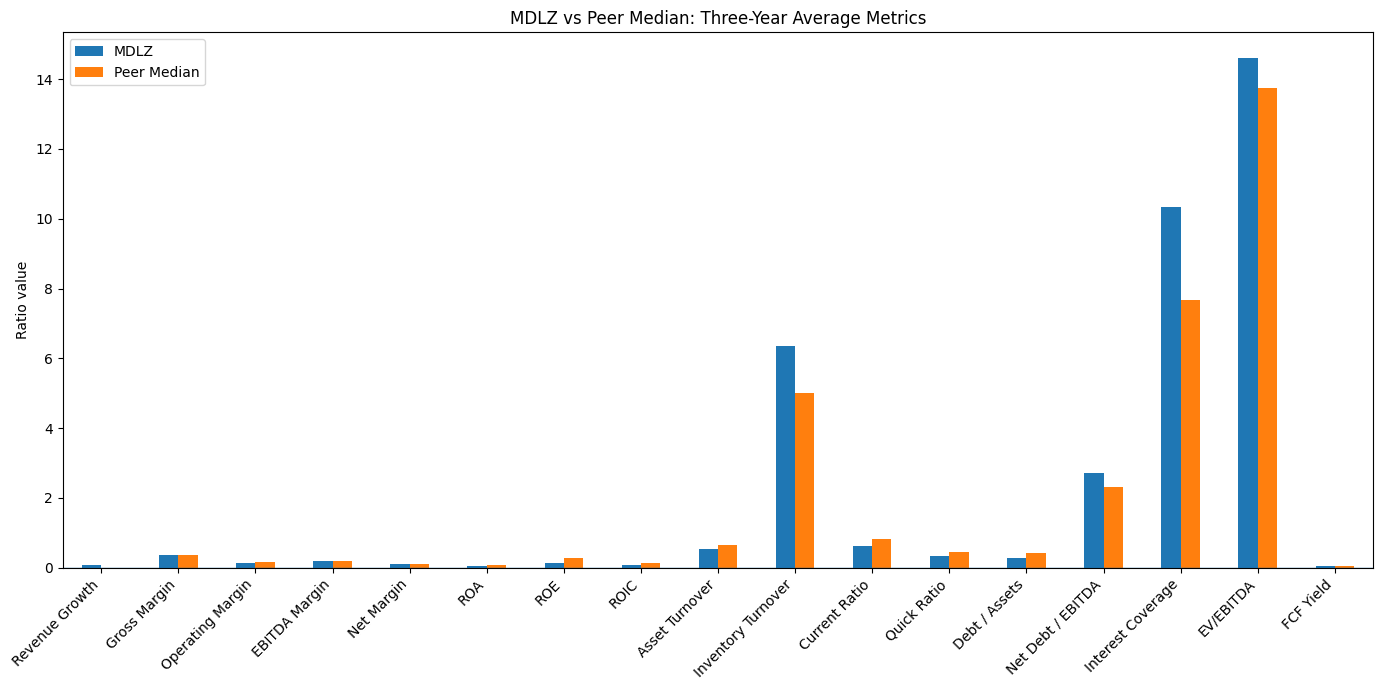

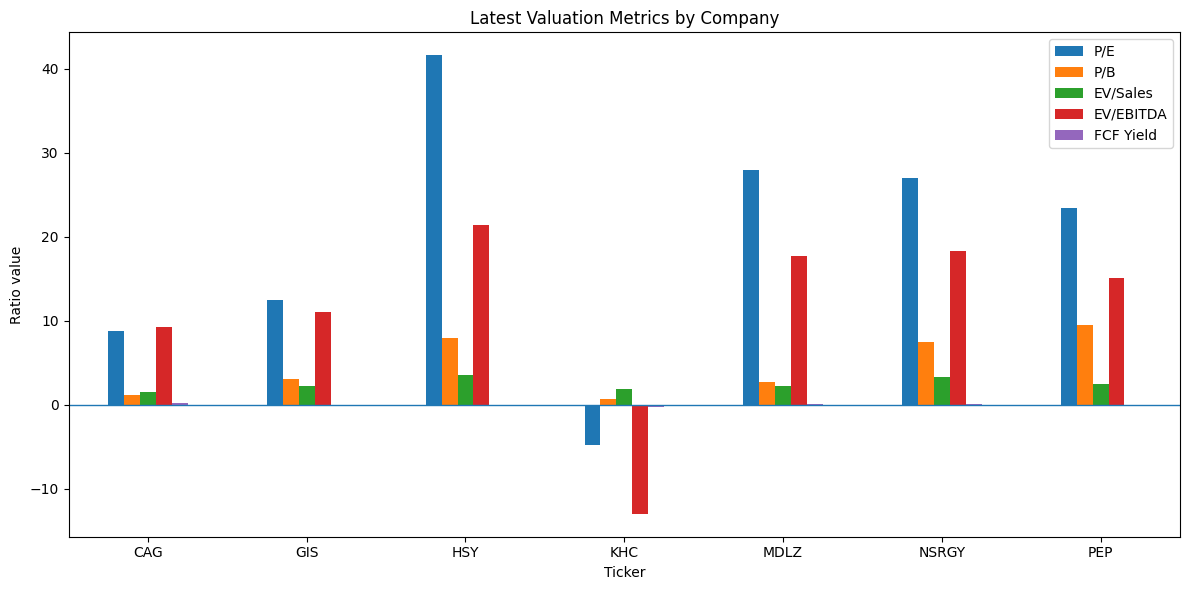

In [22]:

# Visual comparison: MDLZ versus peer median by category

plot_metrics = [
    "Revenue Growth", "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin",
    "ROA", "ROE", "ROIC", "Asset Turnover", "Inventory Turnover",
    "Current Ratio", "Quick Ratio", "Debt / Assets", "Net Debt / EBITDA",
    "Interest Coverage", "EV/EBITDA", "FCF Yield"
]

plot_df = pd.DataFrame({
    "MDLZ": three_year_avg_expanded.loc["MDLZ", plot_metrics],
    "Peer Median": three_year_avg_expanded.loc[[t for t in PEER_TICKERS if t != "MDLZ"], plot_metrics].median()
})

ax = plot_df.plot(kind="bar", figsize=(14, 7))
ax.set_title("MDLZ vs Peer Median: Three-Year Average Metrics")
ax.set_ylabel("Ratio value")
ax.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Separate valuation chart to avoid scale compression
valuation_metrics = ["P/E", "P/B", "EV/Sales", "EV/EBITDA", "FCF Yield"]
valuation_plot = latest_expanded[valuation_metrics].copy()
ax = valuation_plot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Latest Valuation Metrics by Company")
ax.set_ylabel("Ratio value")
ax.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:

# Compact conclusion data: where MDLZ is above/below the peer median

positive_spread_metrics = [
    "Revenue Growth", "Gross Margin", "Operating Margin", "EBITDA Margin", "Net Margin",
    "ROA", "ROE", "ROIC", "Asset Turnover", "Inventory Turnover",
    "Current Ratio", "Quick Ratio", "Interest Coverage", "FCF Yield"
]
negative_spread_metrics = ["Cash Conversion Cycle", "Debt / Assets", "Debt / Equity", "Net Debt / EBITDA", "P/E", "EV/EBITDA"]

summary_rows = []
for m in positive_spread_metrics:
    spread = mdlz_vs_peer_median.loc[m, "MDLZ - Peer Median"]
    summary_rows.append([m, spread, "Favorable" if spread > 0 else "Unfavorable"])
for m in negative_spread_metrics:
    spread = mdlz_vs_peer_median.loc[m, "MDLZ - Peer Median"]
    summary_rows.append([m, spread, "Favorable" if spread < 0 else "Unfavorable"])

mdlz_conclusion_screen = pd.DataFrame(summary_rows, columns=["Metric", "MDLZ Spread vs Peer Median", "Interpretation"])
display(mdlz_conclusion_screen.round(3))

print("Favorable metrics:", (mdlz_conclusion_screen["Interpretation"] == "Favorable").sum())
print("Unfavorable metrics:", (mdlz_conclusion_screen["Interpretation"] == "Unfavorable").sum())


,Metric,MDLZ Spread vs Peer Median,Interpretation
0,Revenue Growth,0.0770,Favorable
1,Gross Margin,-0.0570,Unfavorable
2,Operating Margin,-0.0560,Unfavorable
3,EBITDA Margin,-0.0390,Unfavorable
4,Net Margin,-0.0300,Unfavorable
5,ROA,-0.0320,Unfavorable
6,ROE,-0.1240,Unfavorable
7,ROIC,-0.0530,Unfavorable
8,Asset Turnover,-0.0890,Unfavorable
9,Inventory Turnover,1.2570,Favorable


Favorable metrics: 6
Unfavorable metrics: 14



# Interpretation and Investment Conclusion

## Industry context

The peer set is a defensive consumer-staples group. These firms sell snacks, packaged food, beverages, confectionery, and related branded products. The attractive part of the industry is resilience: demand is relatively stable, brands can support some pricing power, distribution networks are hard to replicate, and cash generation can be steady across the cycle. The unattractive part is that growth is usually slow, input-cost inflation can compress margins, and high brand value often means investors pay rich valuation multiples even when volume growth is modest.

That is the basic tradeoff in this notebook: the best companies are not necessarily the cheapest, and the cheapest companies are not necessarily the best.

## How MDLZ stacks up

MDLZ looks like a **solid, defensible, above-average growth compounder**, but not the single highest-quality name in the peer group on every metric. It compares especially well on revenue growth and has reasonable cash generation, but it does not dominate the group on margins, ROIC, liquidity, or valuation.

The expanded ratio tables show the following pattern:

1. **Growth:** MDLZ is one of the better growth stories in this peer group. Its latest and three-year revenue growth figures compare favorably with slower-growth or contracting peers such as KHC, CAG, GIS, and NSRGY. This matters because packaged-food companies often struggle to grow volumes once pricing benefits fade.

2. **Margins:** MDLZ has respectable margins, but it does not match the highest-margin peers. PEP and NSRGY show stronger gross-margin profiles, while GIS and KHC often screen better on operating margin. MDLZ is therefore not simply the highest-margin business; its case rests more on balance, brand durability, geographic diversification, and growth than on margin dominance.

3. **Turnover and working capital:** The newly added activity ratios show that MDLZ is operationally credible. Its inventory turnover and cash-conversion-cycle metrics are not alarming, and its negative or low cash-conversion-cycle profile is consistent with a branded food company that receives supplier financing and turns receivables/inventory efficiently. This is an important improvement over the earlier notebook because turnover ratios help separate genuine operating strength from pure margin optics.

4. **Liquidity:** MDLZ, like many consumer-staples firms, does not carry a high current ratio. This should not automatically be treated as distress because predictable cash flows and supplier credit reduce the need for a large current-asset cushion. Still, MDLZ is not a liquidity standout; the current and quick ratios show that the company is managed with a relatively lean working-capital structure.

5. **Leverage:** MDLZ carries meaningful debt but does not look like the most financially strained company in the set. Net debt / EBITDA and interest coverage are the key ratios here. MDLZ appears more leveraged than a pristine balance-sheet compounder, but not obviously impaired. KHC looks weaker because the latest data include negative or distorted earnings/EBITDA and poor proxy FCF, while GIS and PEP carry substantial leverage but with steadier profitability.

6. **Valuation:** MDLZ does not screen as obviously cheap. Its P/E and EV/EBITDA are elevated relative to lower-multiple names such as GIS and CAG, though the latter appear cheaper partly because they have weaker growth and/or weaker operating narratives. MDLZ's valuation is closer to a quality-growth staple than a deep-value staple.

## Buy, sell, or hold?

Based only on the uploaded historical financials, price data, bond-yield inputs, and the DCF/WACC framework in this notebook, MDLZ is best described as a **Hold / selective Buy on weakness**, not an outright Sell and not an obvious table-pounding Buy at any price.

The case for **Buy** is that MDLZ has one of the better growth profiles in the peer group, durable brands, solid factor/return behavior, reasonable cash generation, and no obvious balance-sheet crisis. The case against an aggressive Buy is valuation: the market appears to recognize much of the quality. Unless the DCF assumptions imply a clear margin of safety, MDLZ should be treated as a high-quality defensive compounder whose attractiveness depends heavily on entry price.

A clean decision rule for the notebook is:

- **Buy / Accumulate:** when MDLZ trades below the DCF-implied value under conservative assumptions, or when EV/EBITDA and P/E fall below peer-quality-adjusted medians.
- **Hold:** when MDLZ trades near fair value but continues to compound revenue and FCF at peer-leading rates.
- **Sell / Avoid:** if growth slows toward the low-growth peer group while the stock still trades at a premium multiple, or if leverage rises without a corresponding improvement in margins and FCF.

My data-based conclusion from the uploaded files is: **MDLZ is a Hold, with a bias toward Buy on valuation pullbacks.**

## Which competitors look attractive?

**PEP** looks like one of the strongest businesses qualitatively. It has large scale, high gross margins, strong brand power, and a diversified snack-and-beverage platform. The weakness is valuation and leverage: it may be a great business without being the cheapest stock.

**HSY** screens well in a composite rank because of profitability and brand economics, but the latest valuation and proxy FCF numbers make it look less attractive on price. HSY may be a high-quality company that requires a disciplined entry price.

**GIS** looks more attractive as a value candidate. Its valuation multiples are lower, profitability is respectable, and leverage is manageable but not trivial. The main concern is weak growth. GIS looks like a cheaper, mature cash-flow story rather than a dynamic compounder.

**CAG** screens cheap and, in the proxy calculation, cash-generative, but it has weaker margins and weaker growth. It may appeal to value investors, but the operating quality is not as strong as the best names in the group.

**NSRGY** has strong gross margins and global scale, but the data show weaker recent growth and a richer valuation. It looks like a high-quality global staple, but not obviously cheap in this sample.

## Which competitors look weak?

**KHC** looks weakest in the uploaded data. Its valuation appears optically cheap on book and sales measures, but that cheapness is paired with negative or distorted latest earnings/cash-flow metrics and an unattractive growth profile. This is exactly the kind of company where low multiples can be a value opportunity or a value trap. The notebook should treat KHC separately by normalizing earnings and excluding large one-time charges before making a final judgment.

**CAG** also looks operationally weaker than MDLZ, PEP, HSY, and NSRGY, though not necessarily uninvestable. It is more of a low-growth value/restructuring candidate than a high-quality compounder.

## Coherent story

The industry is splitting into three broad camps:

1. **Quality compounders:** PEP, HSY, NSRGY, and MDLZ. These firms have stronger brands and stronger long-run economics, but valuations often reflect that quality.
2. **Balanced quality-growth name:** MDLZ. It is not the cheapest and not the highest-margin, but it combines scale, growth, brand durability, and acceptable leverage better than most peers.
3. **Value / turnaround names:** GIS, CAG, and especially KHC. These firms can look cheap, but the cheapness is compensation for slower growth, weaker operating momentum, or earnings-quality concerns.

MDLZ fits in the middle-upper tier: better growth than most packaged-food peers, less diversified than PEP, less pure confectionery-premium than HSY, less globally massive than NSRGY, but cleaner and more attractive than the weaker value names. The most defensible conclusion is that **MDLZ is a good company at a fair-to-full price**. It becomes especially attractive if the stock price falls enough to create a DCF margin of safety while the operating ratios remain intact.
